# 01 - Variable Correlation (Step 1)

Explores how `pressure`, `precipitation`, and `luminous_intensity` relate to
each other at the stations the Step 0 coverage audit rates in scope for
analysis: every **GO** and **CONDITIONAL-GO** station, each used over its
full joint sensor-overlap span (the intersection of all three sensors'
recorded spans) — no per-station rescue-window search. The exact roster is
derived at run time from `reports/data_audit/station_recommendation.csv`
(`uema.silver.analysis_stations`), not hardcoded here — see `station_scope.csv`
in this notebook's own output directory for which stations qualified on the
run that produced these results and what date range each used. NO-GO
stations are excluded.

The question this notebook answers: are these three sensors correlated
enough, at these stations, to justify treating them jointly (multivariate)
in later modeling steps, or independent enough that per-sensor (univariate)
treatment loses little? That's decided at the end from the numbers computed
here, not assumed going in.

Outputs (`reports/variable_correlation/`): the station scope table, per-station
Pearson/Spearman correlation matrices (CSV + heatmap), cross-correlation (CCF)
plots per station per sensor pair, and correlation matrices conditioned on
time-of-day and season.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

from uema.audit import build_coverage_table, station_recommendation
from uema.correlation import PRECIPITATION, ccf, conditioned_correlation, pairwise_correlation, primary_method
from uema.silver import analysis_stations, consolidate_stations, fill_gaps, resample_10min
from uema.style import PALETTE, apply_style

apply_style()

REPORT_DIR = Path("../reports/variable_correlation")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = ("pressure", "precipitation", "luminous_intensity")
PAIRS = [("pressure", "precipitation"), ("pressure", "luminous_intensity"), ("precipitation", "luminous_intensity")]

# Fixed pair -> color assignment (project convention: fixed categorical order,
# never re-cycled when the series set changes).
PAIR_COLORS = {
    PAIRS[0]: PALETTE["indigo"],
    PAIRS[1]: PALETTE["burnt_sienna"],
    PAIRS[2]: PALETTE["violet"],
}

# Diverging colormap for correlation heatmaps (polarity: negative/zero/positive),
# built from two brand colors either side of a neutral white midpoint rather than
# a generic rainbow.
DIVERGING_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "uema_diverging", [PALETTE["burnt_sienna"], "#FFFFFF", PALETTE["indigo"]]
)

# Station roster + per-station trim window, derived from Step 0's verdicts --
# not hardcoded, so a station that newly clears GO or CONDITIONAL-GO on a
# future audit run is picked up automatically. Every in-scope station uses
# its full joint span -- no rescue-window search (see uema.silver.analysis_stations).
recommendation = station_recommendation(build_coverage_table())
scope = analysis_stations(recommendation)
scope.to_csv(REPORT_DIR / "station_scope.csv")
STATIONS = list(scope.index)

# Region label inferred from station slug (text before the first "_", or the
# whole slug if there's no "_") -- a label for context, not a grouping key.
def region_of(station: str) -> str:
    return station.split("_")[0]

REGION = {s: region_of(s) for s in STATIONS}
scope


,window_start,window_end,decision
station,,,
recinto-esparza,2024-11-21 15:00:00,2026-08-16 00:00:00,GO
recinto-santa-cruz,2024-12-12 17:00:00,2026-08-16 00:00:00,CONDITIONAL-GO
sede-atlantico_turrialba,2024-10-03 11:40:00,2026-08-16 00:00:00,GO
sede-central_finca-1,2025-11-08 17:40:00,2026-08-16 00:00:00,GO
sede-central_finca-2,2025-04-30 08:30:00,2026-07-21 15:20:00,CONDITIONAL-GO
sede-central_finca-3,2024-12-12 16:10:00,2026-08-16 00:00:00,CONDITIONAL-GO
sede-central_losic-norte-1,2026-04-07 19:10:00,2026-08-16 00:00:00,CONDITIONAL-GO
sede-central_losic-norte-2,2025-10-12 08:00:00,2026-04-04 15:00:00,CONDITIONAL-GO
sede-central_sabanilla,2026-04-29 09:40:00,2026-08-16 00:00:00,CONDITIONAL-GO


## Load and consolidate

Each in-scope station's three raw sensor CSVs are loaded and joined on a
shared time index via `uema.silver.consolidate_stations`, trimmed to that
station's full joint sensor-overlap span (no per-station rescue window --
every GO/CONDITIONAL-GO station is used as-is), resampled onto a strict
10-minute grid, then short gaps (<= 6h) are linearly bridged -- longer gaps
are deliberately left as `NaN` and excluded pairwise by the correlation
calls below rather than filled. Accepting a station's actual, sometimes
blocky, coverage and handling it this way (short-gap interpolation +
pairwise exclusion for the rest) is the standard approach, rather than
hunting for an optimal clean sub-window per station.


In [2]:
raw_frames = consolidate_stations(recommendation)

station_data: dict[str, pd.DataFrame] = {}
for station, df in raw_frames.items():
    df = resample_10min(df)
    df = fill_gaps(df, max_gap="6h")
    station_data[station] = df

missingness = pd.DataFrame(
    {station: df.isna().mean() * 100 for station, df in station_data.items()}
).T
missingness.index.name = "station"
missingness.columns = [f"pct_missing_after_fill_{c}" for c in missingness.columns]
missingness.to_csv(REPORT_DIR / "post_fill_missingness.csv")
missingness


,pct_missing_after_fill_pressure,pct_missing_after_fill_precipitation,pct_missing_after_fill_luminous_intensity
station,,,
recinto-esparza,3.094561,0.000000,3.094561
recinto-santa-cruz,33.005782,0.000000,33.005782
sede-atlantico_turrialba,2.107215,0.000000,2.107215
sede-central_finca-1,4.232018,0.000000,4.232018
sede-central_finca-2,26.896445,0.000000,26.896445
sede-central_finca-3,36.419711,9.773719,36.419711
sede-central_losic-norte-1,3.648000,0.000000,3.648000
sede-central_losic-norte-2,50.994064,17.068409,50.994064
sede-central_sabanilla,1.150969,0.000000,1.150969


## Per-station correlation matrices

Pearson and Spearman correlation, all three sensor pairs, per station.
Spearman is the primary read for any pair involving `precipitation` (zero-
inflated: most 10-minute bins are exactly 0.0mm, which distorts Pearson) --
Pearson is still shown alongside for comparison.


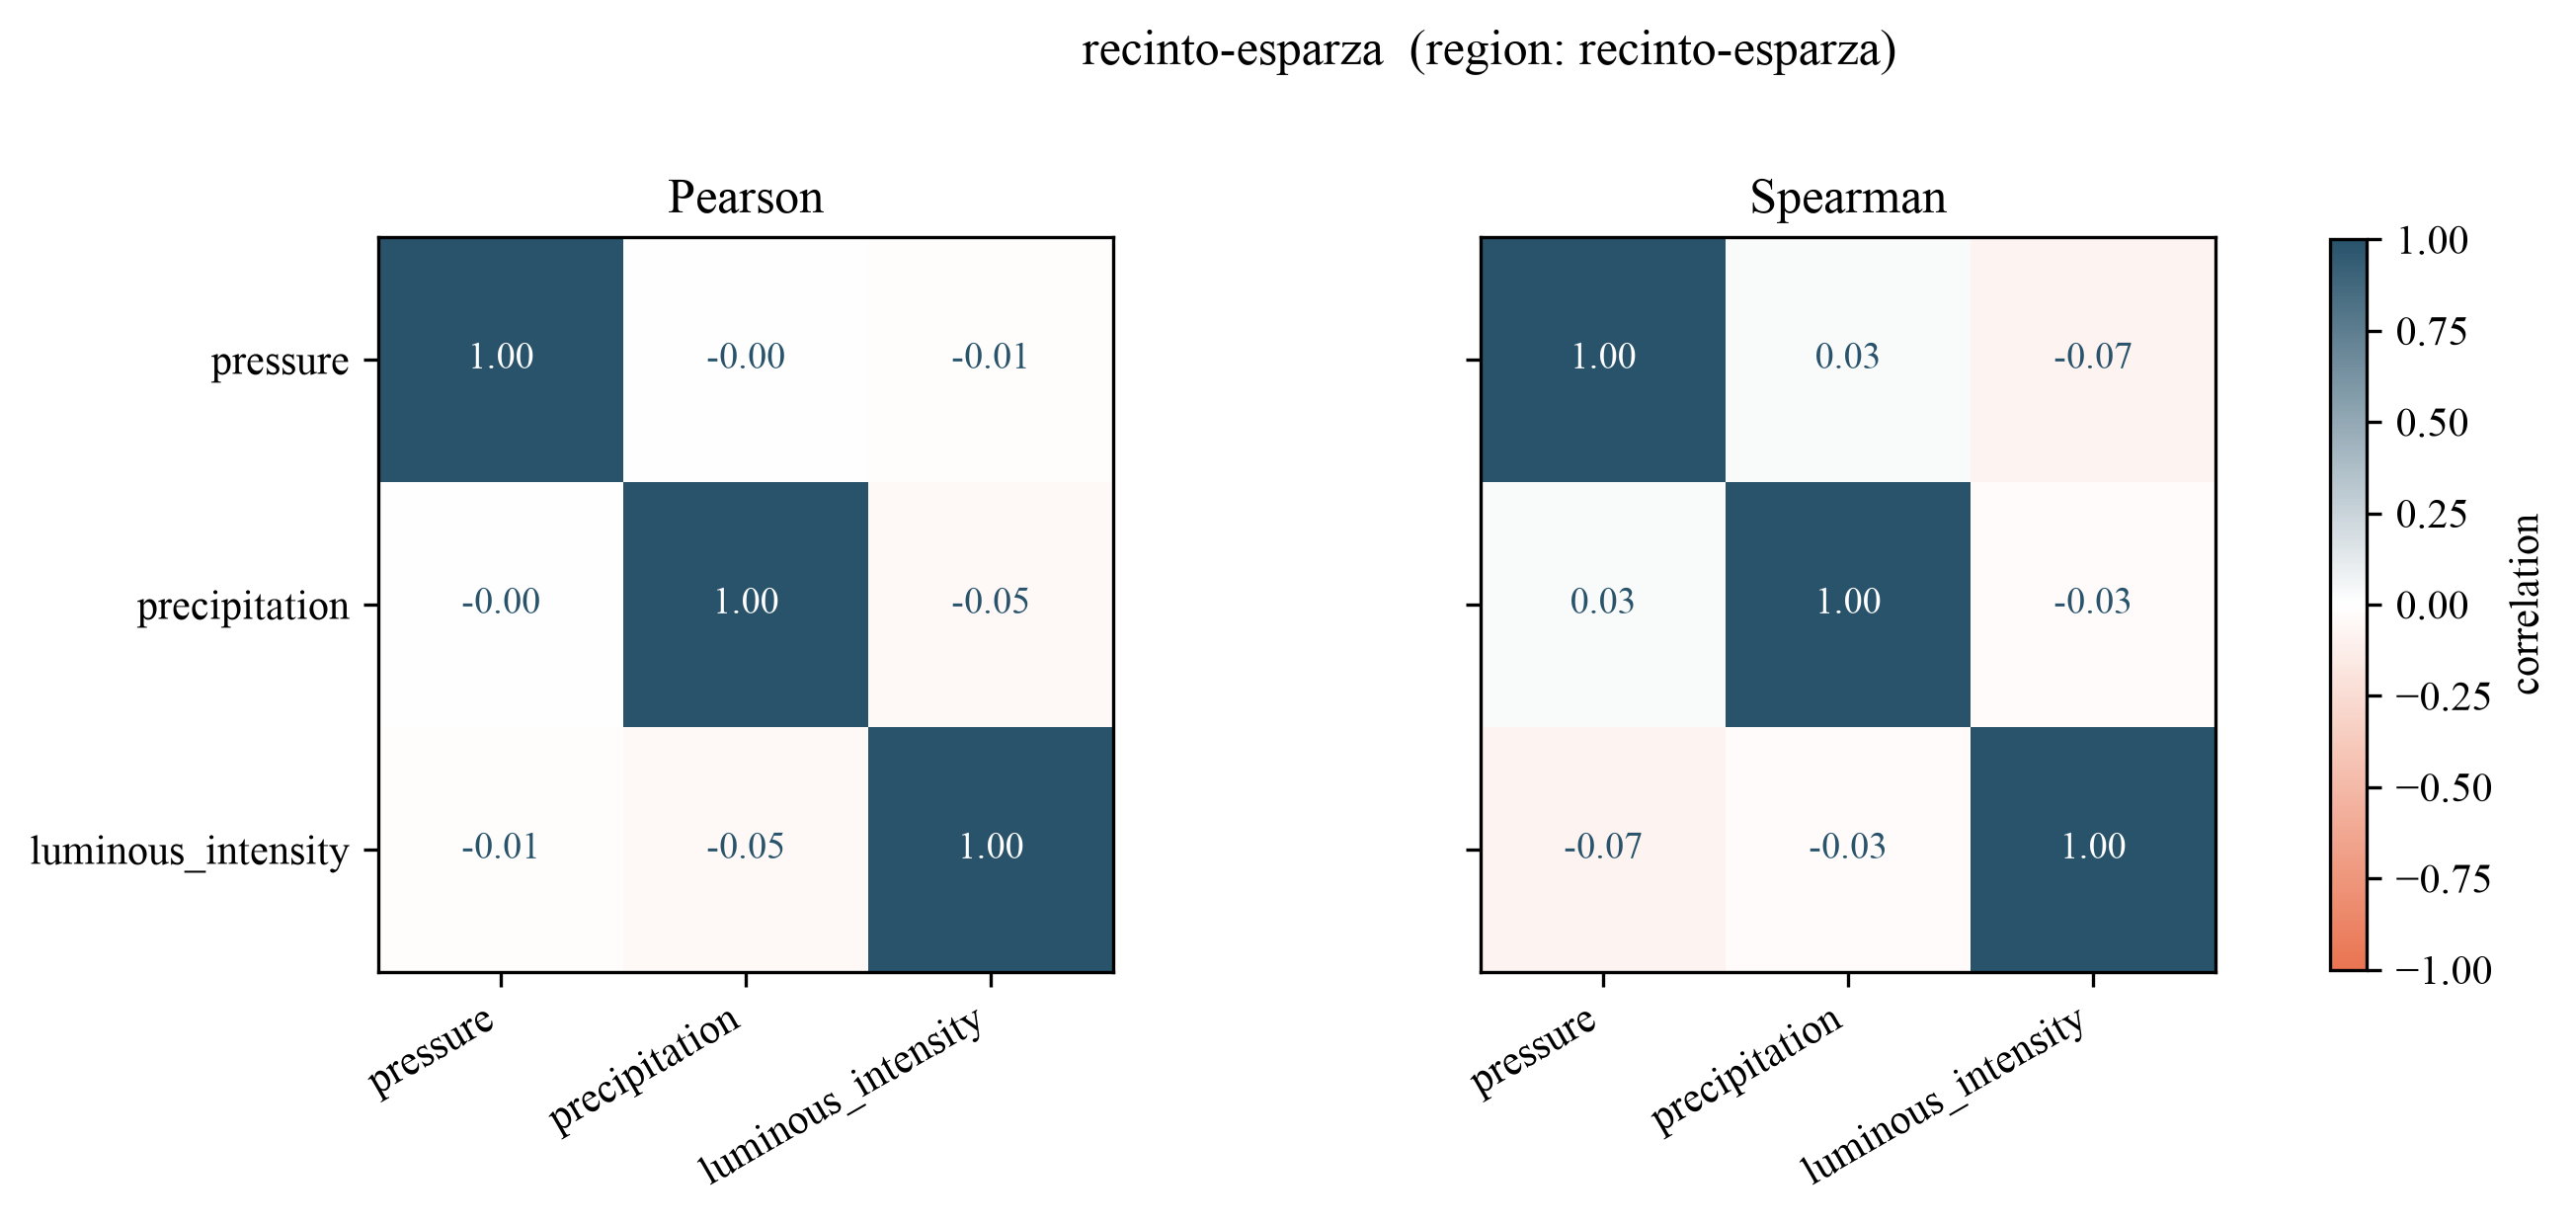

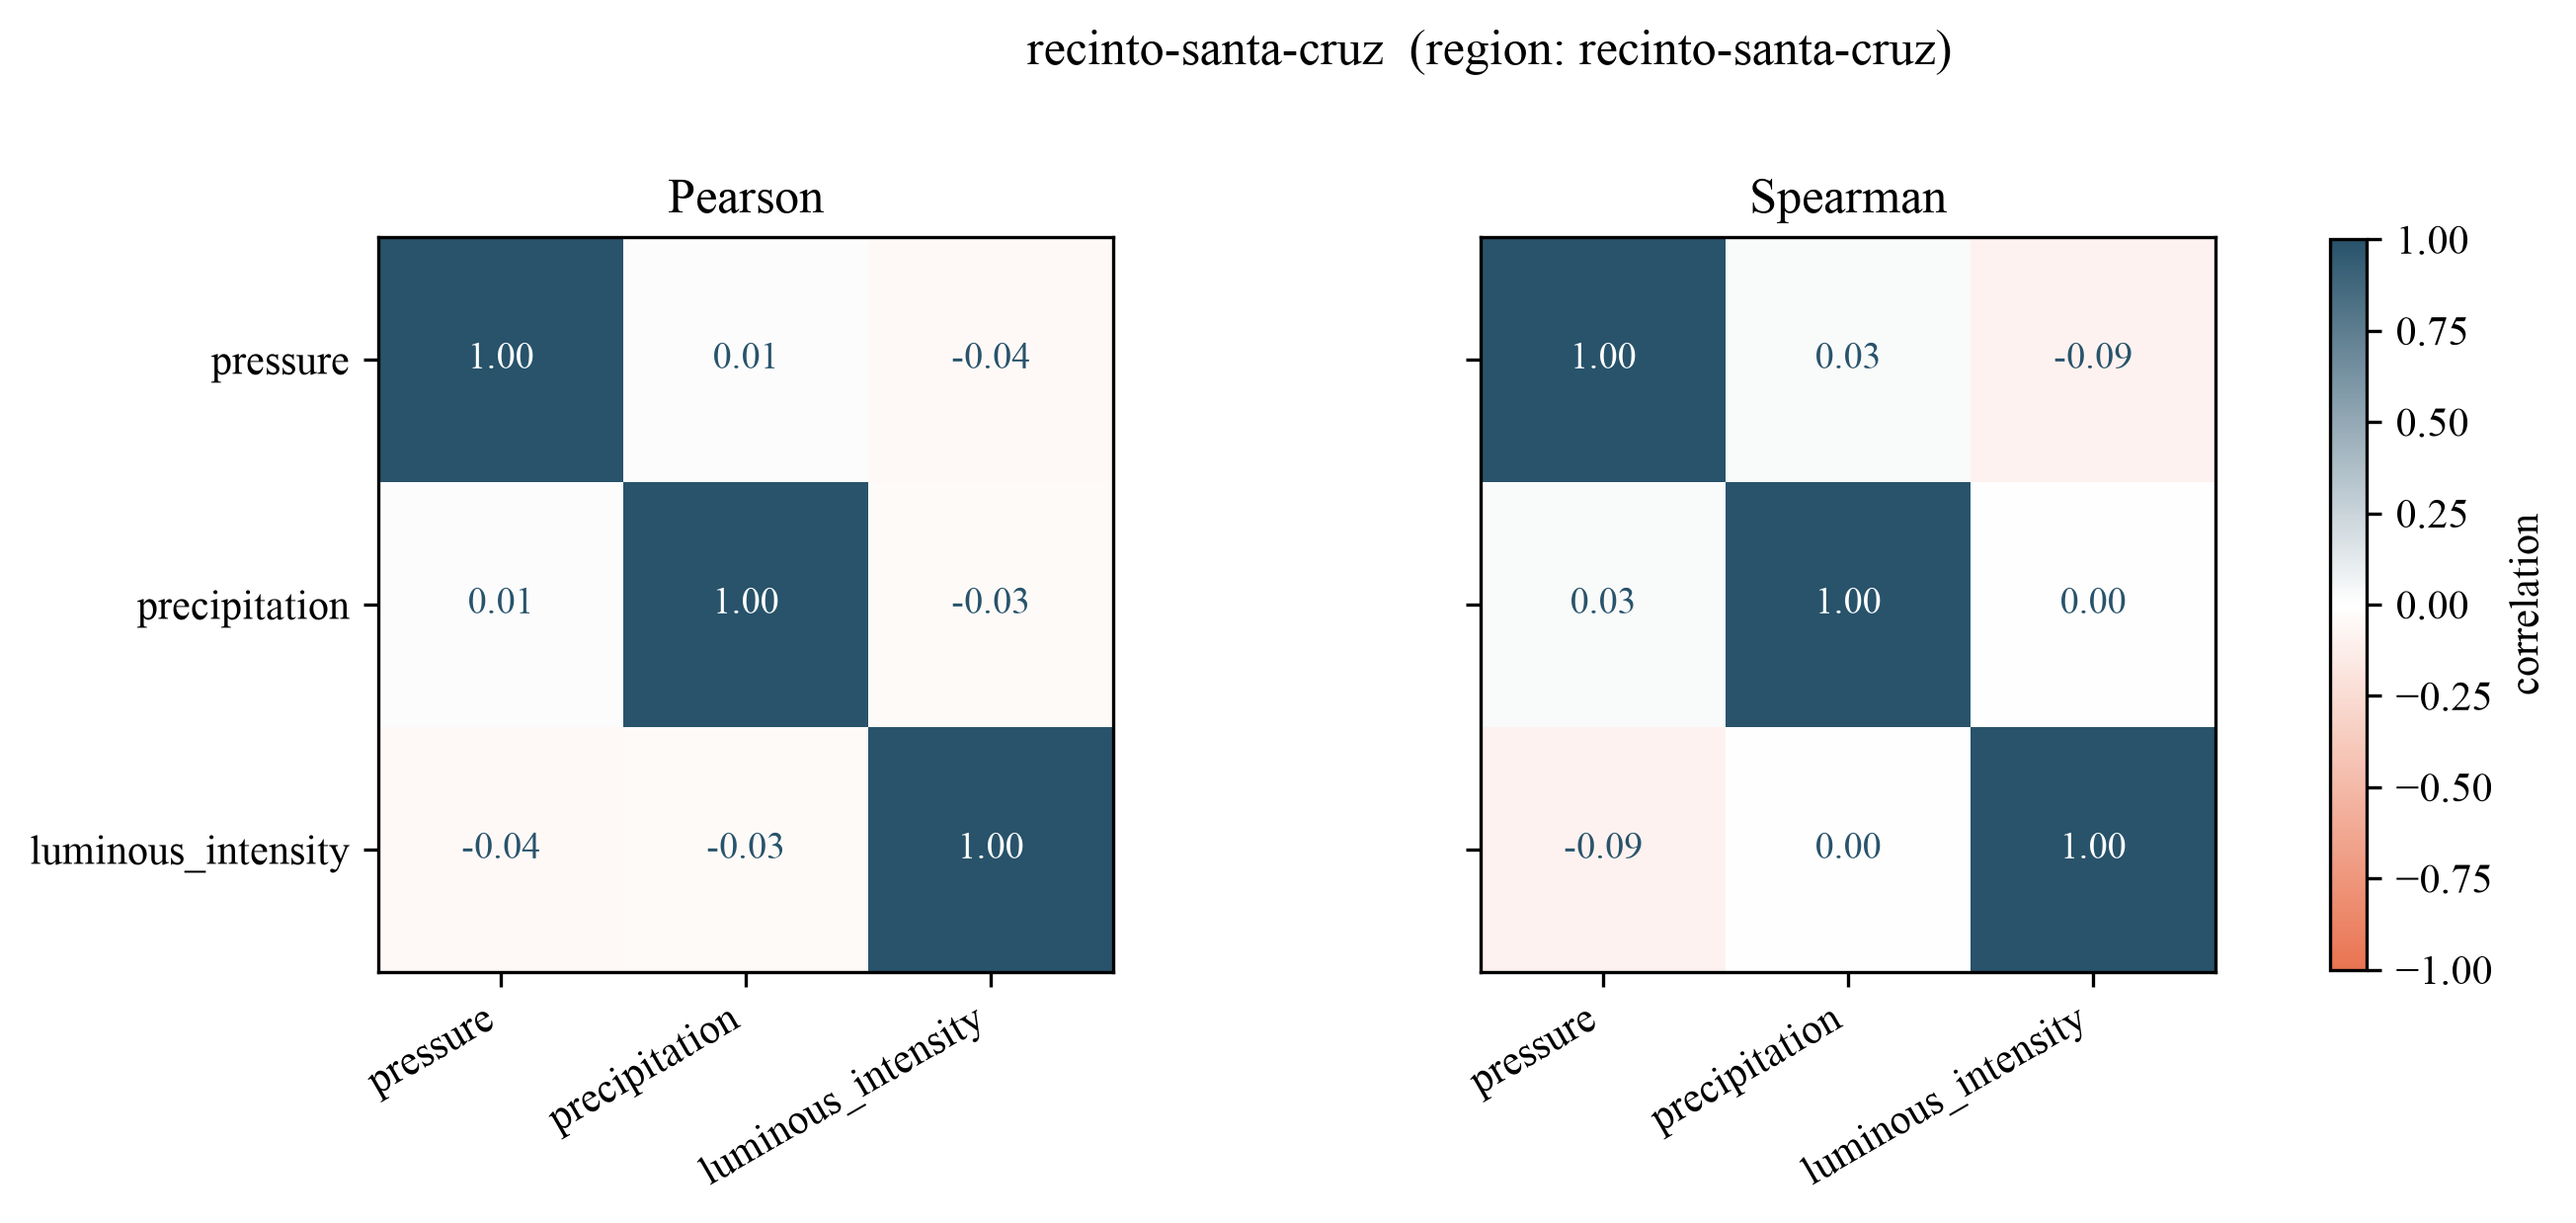

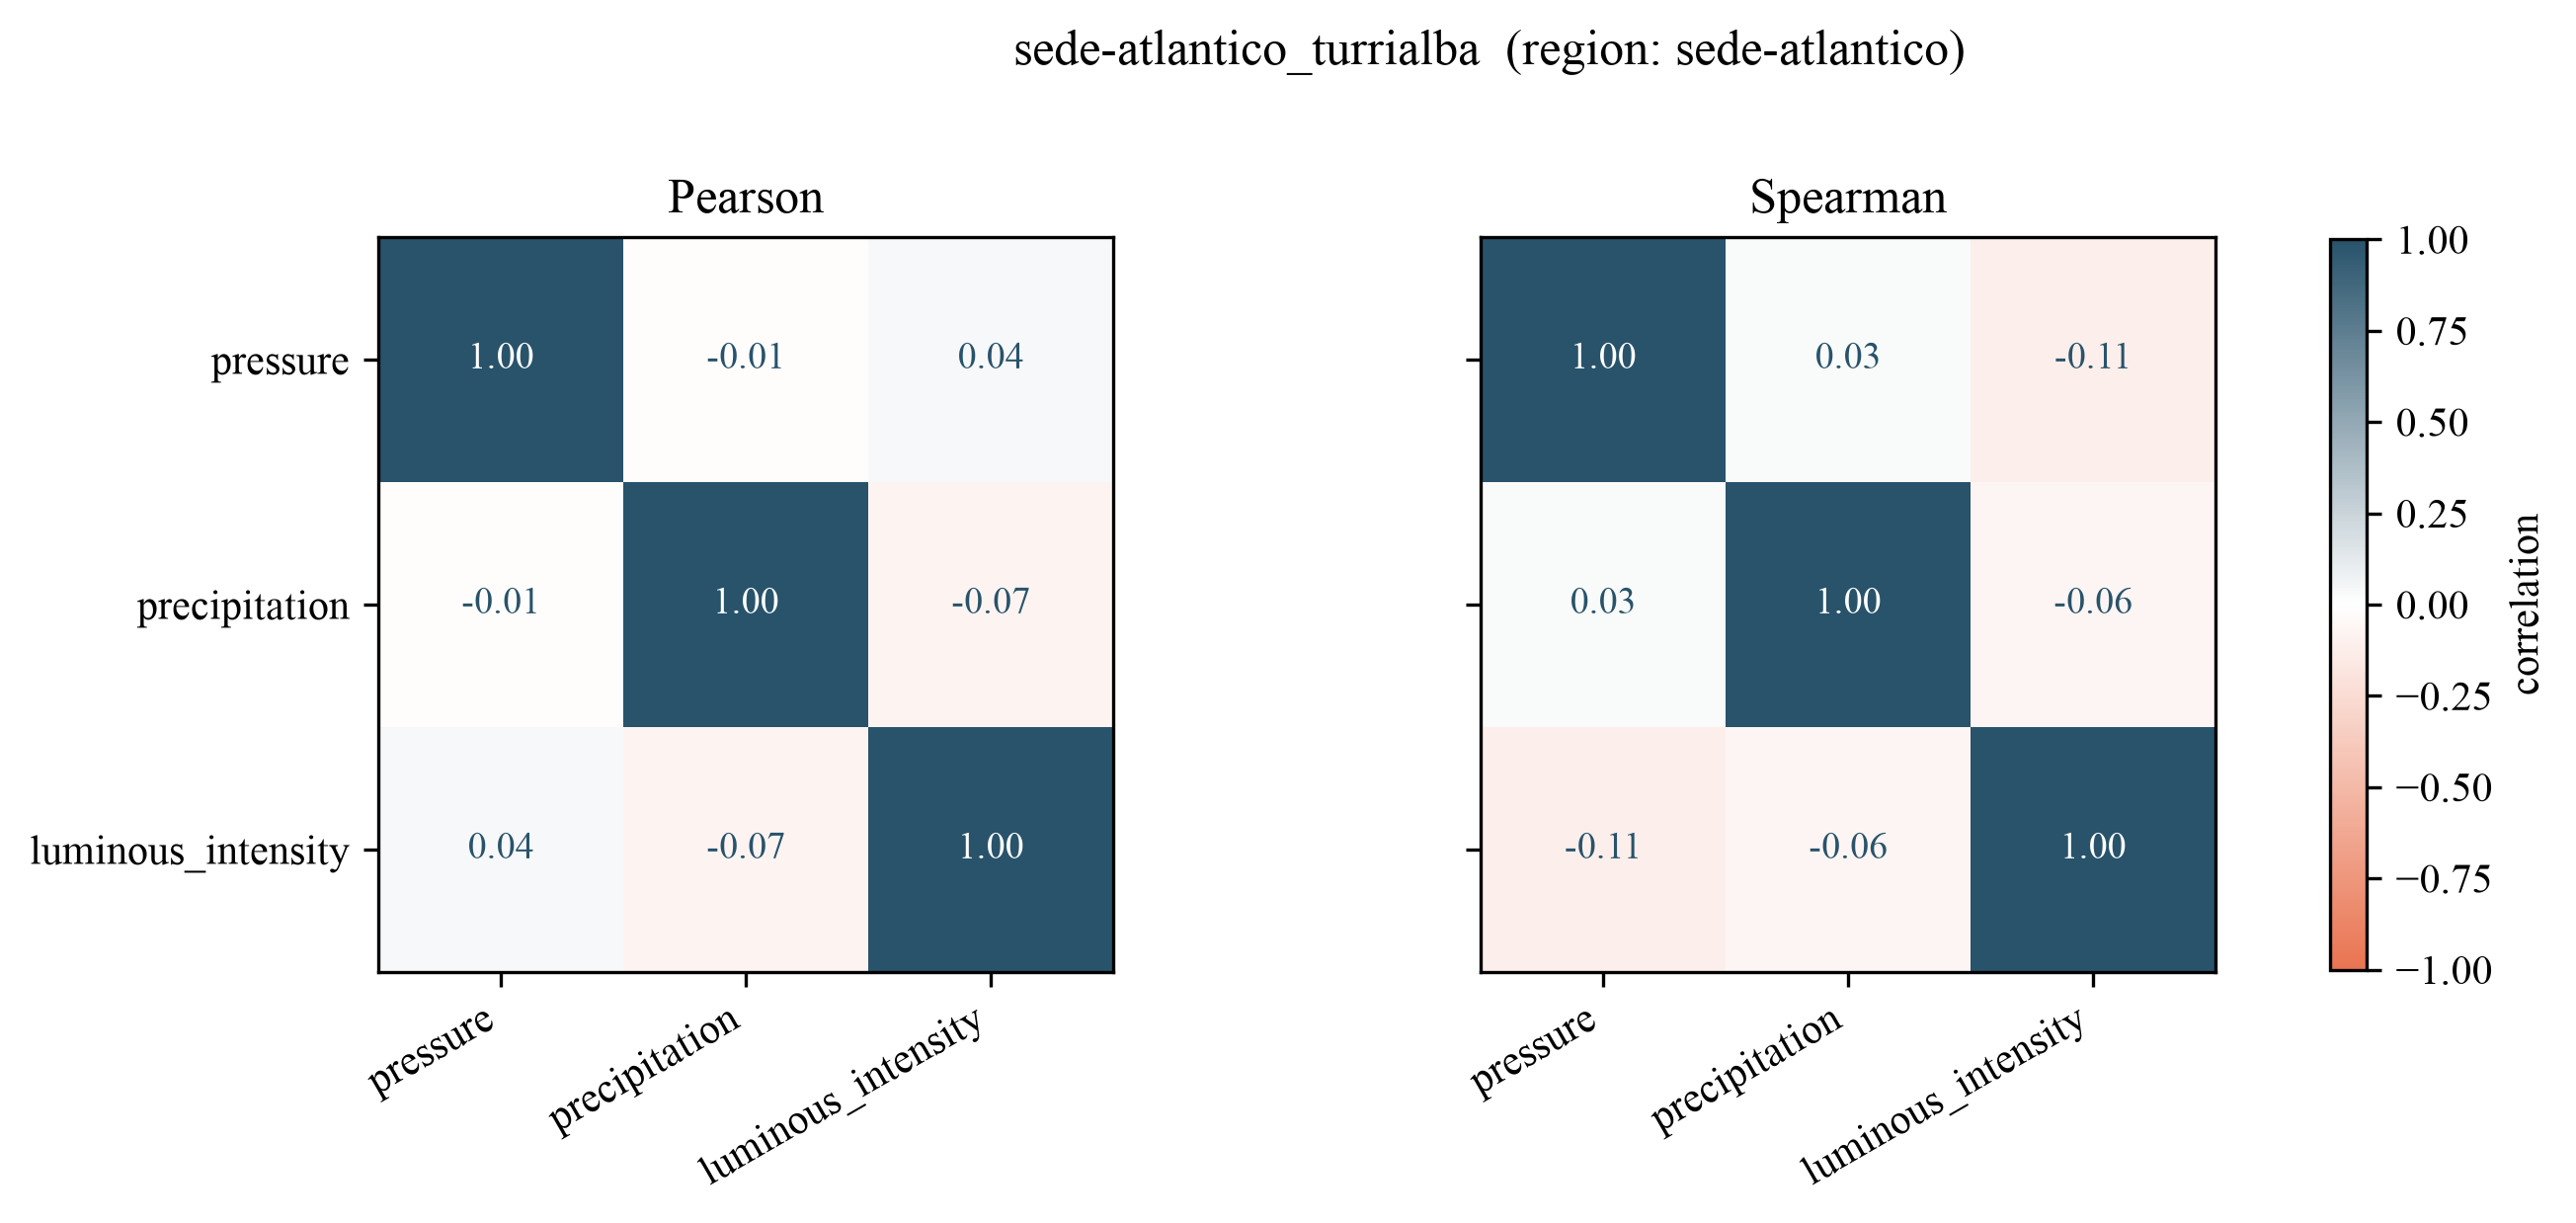

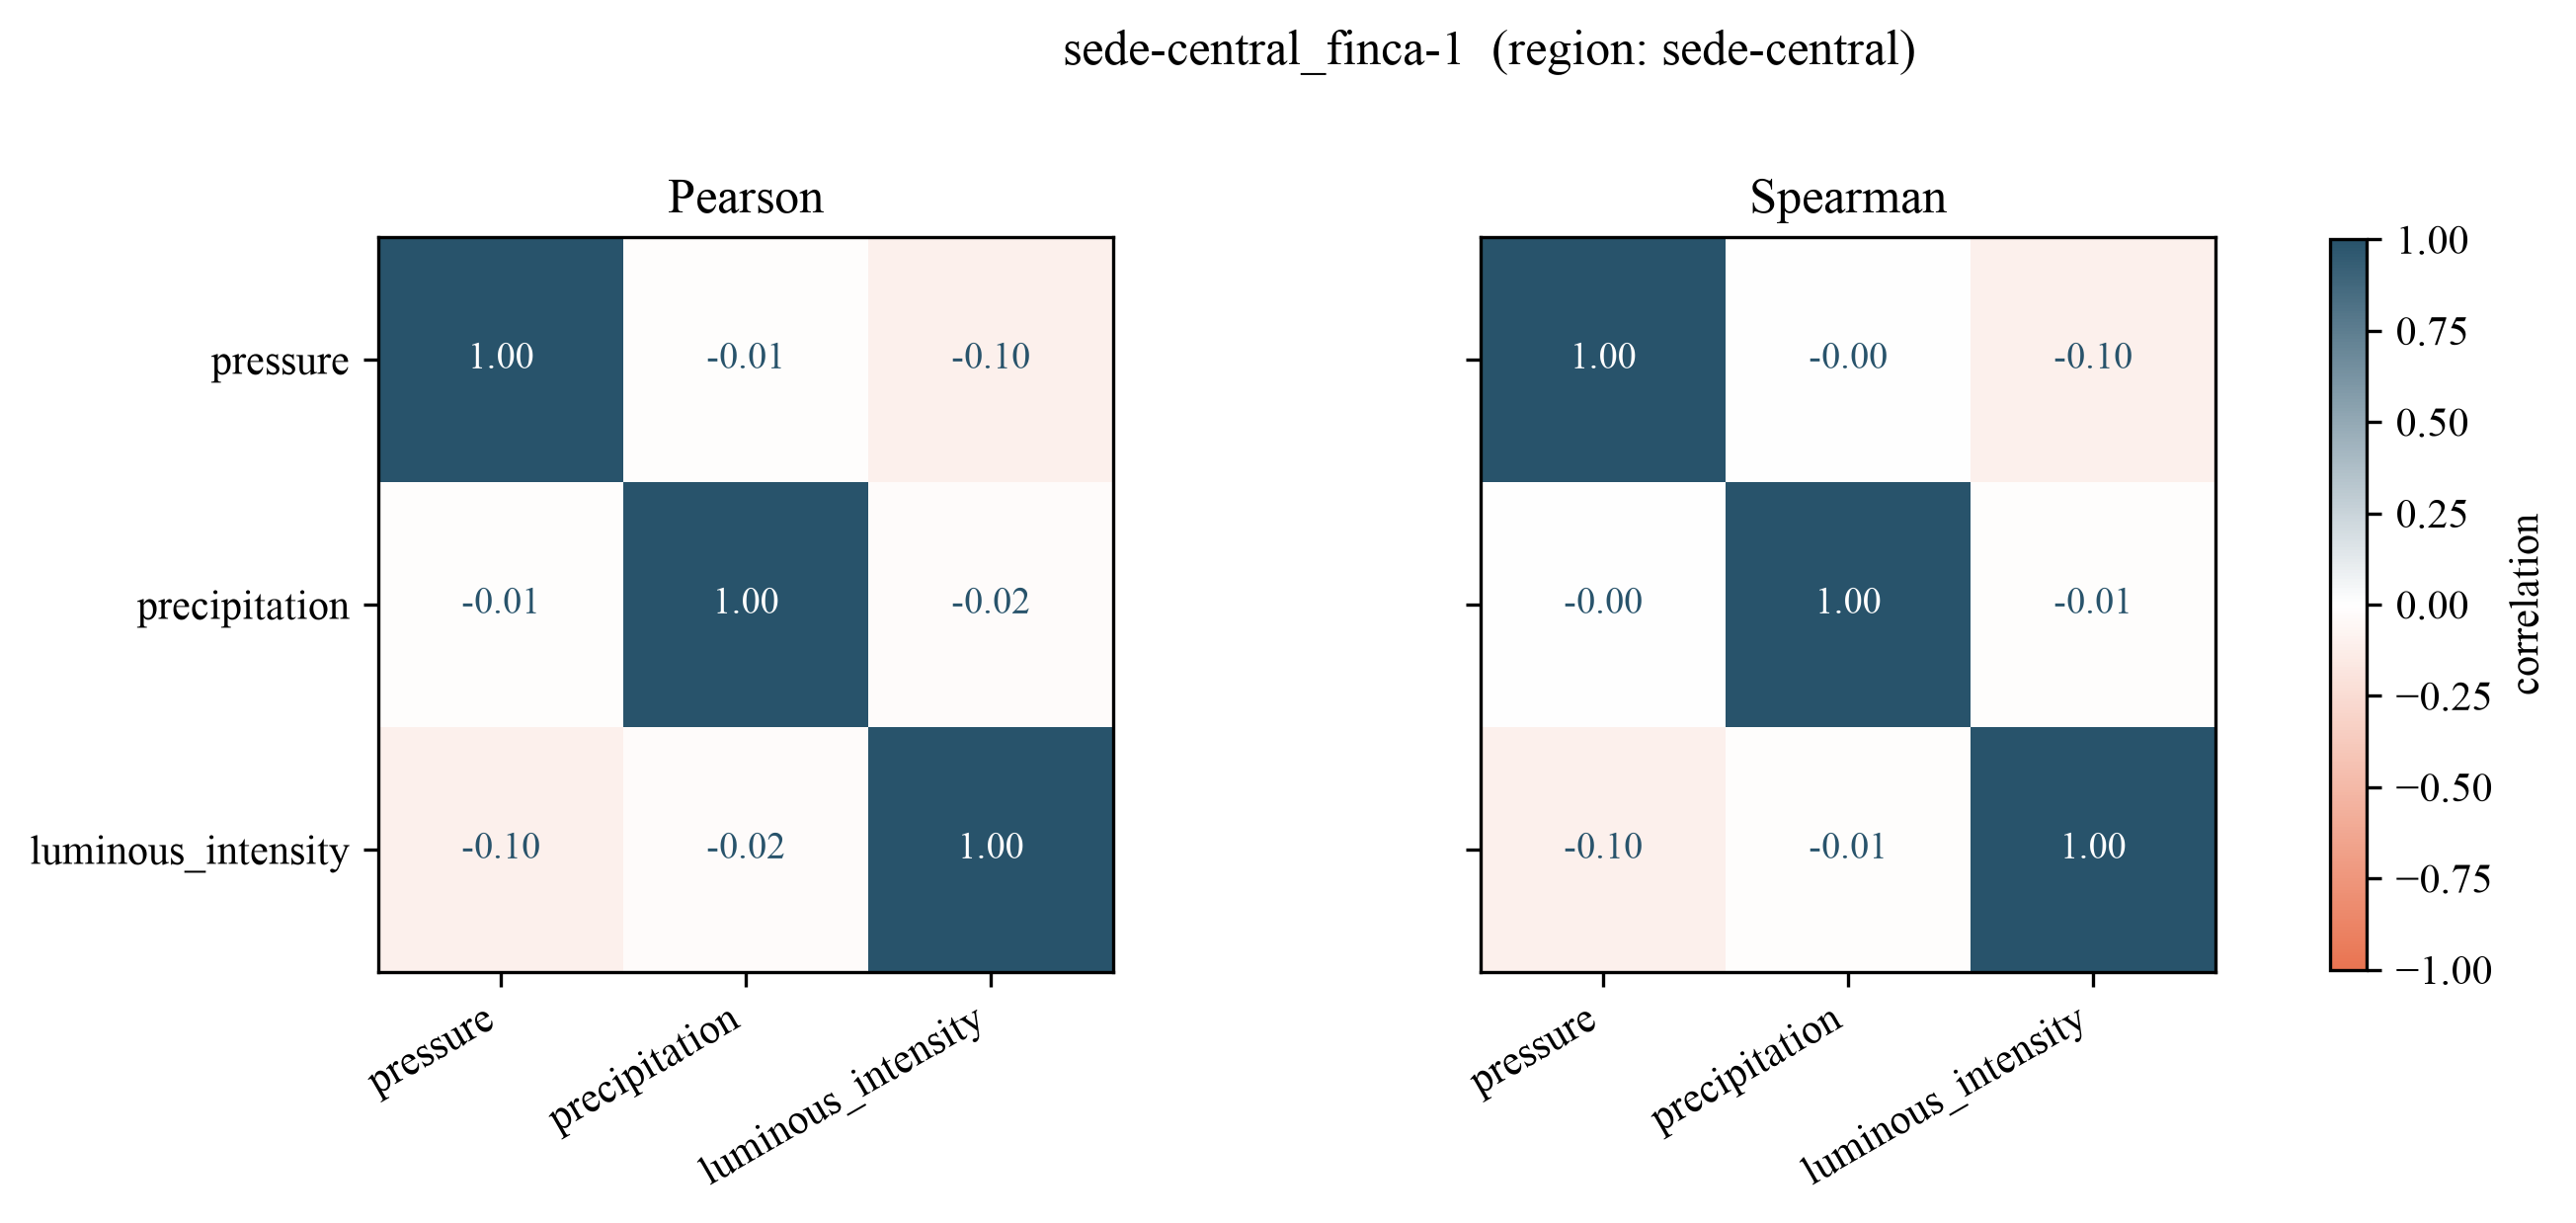

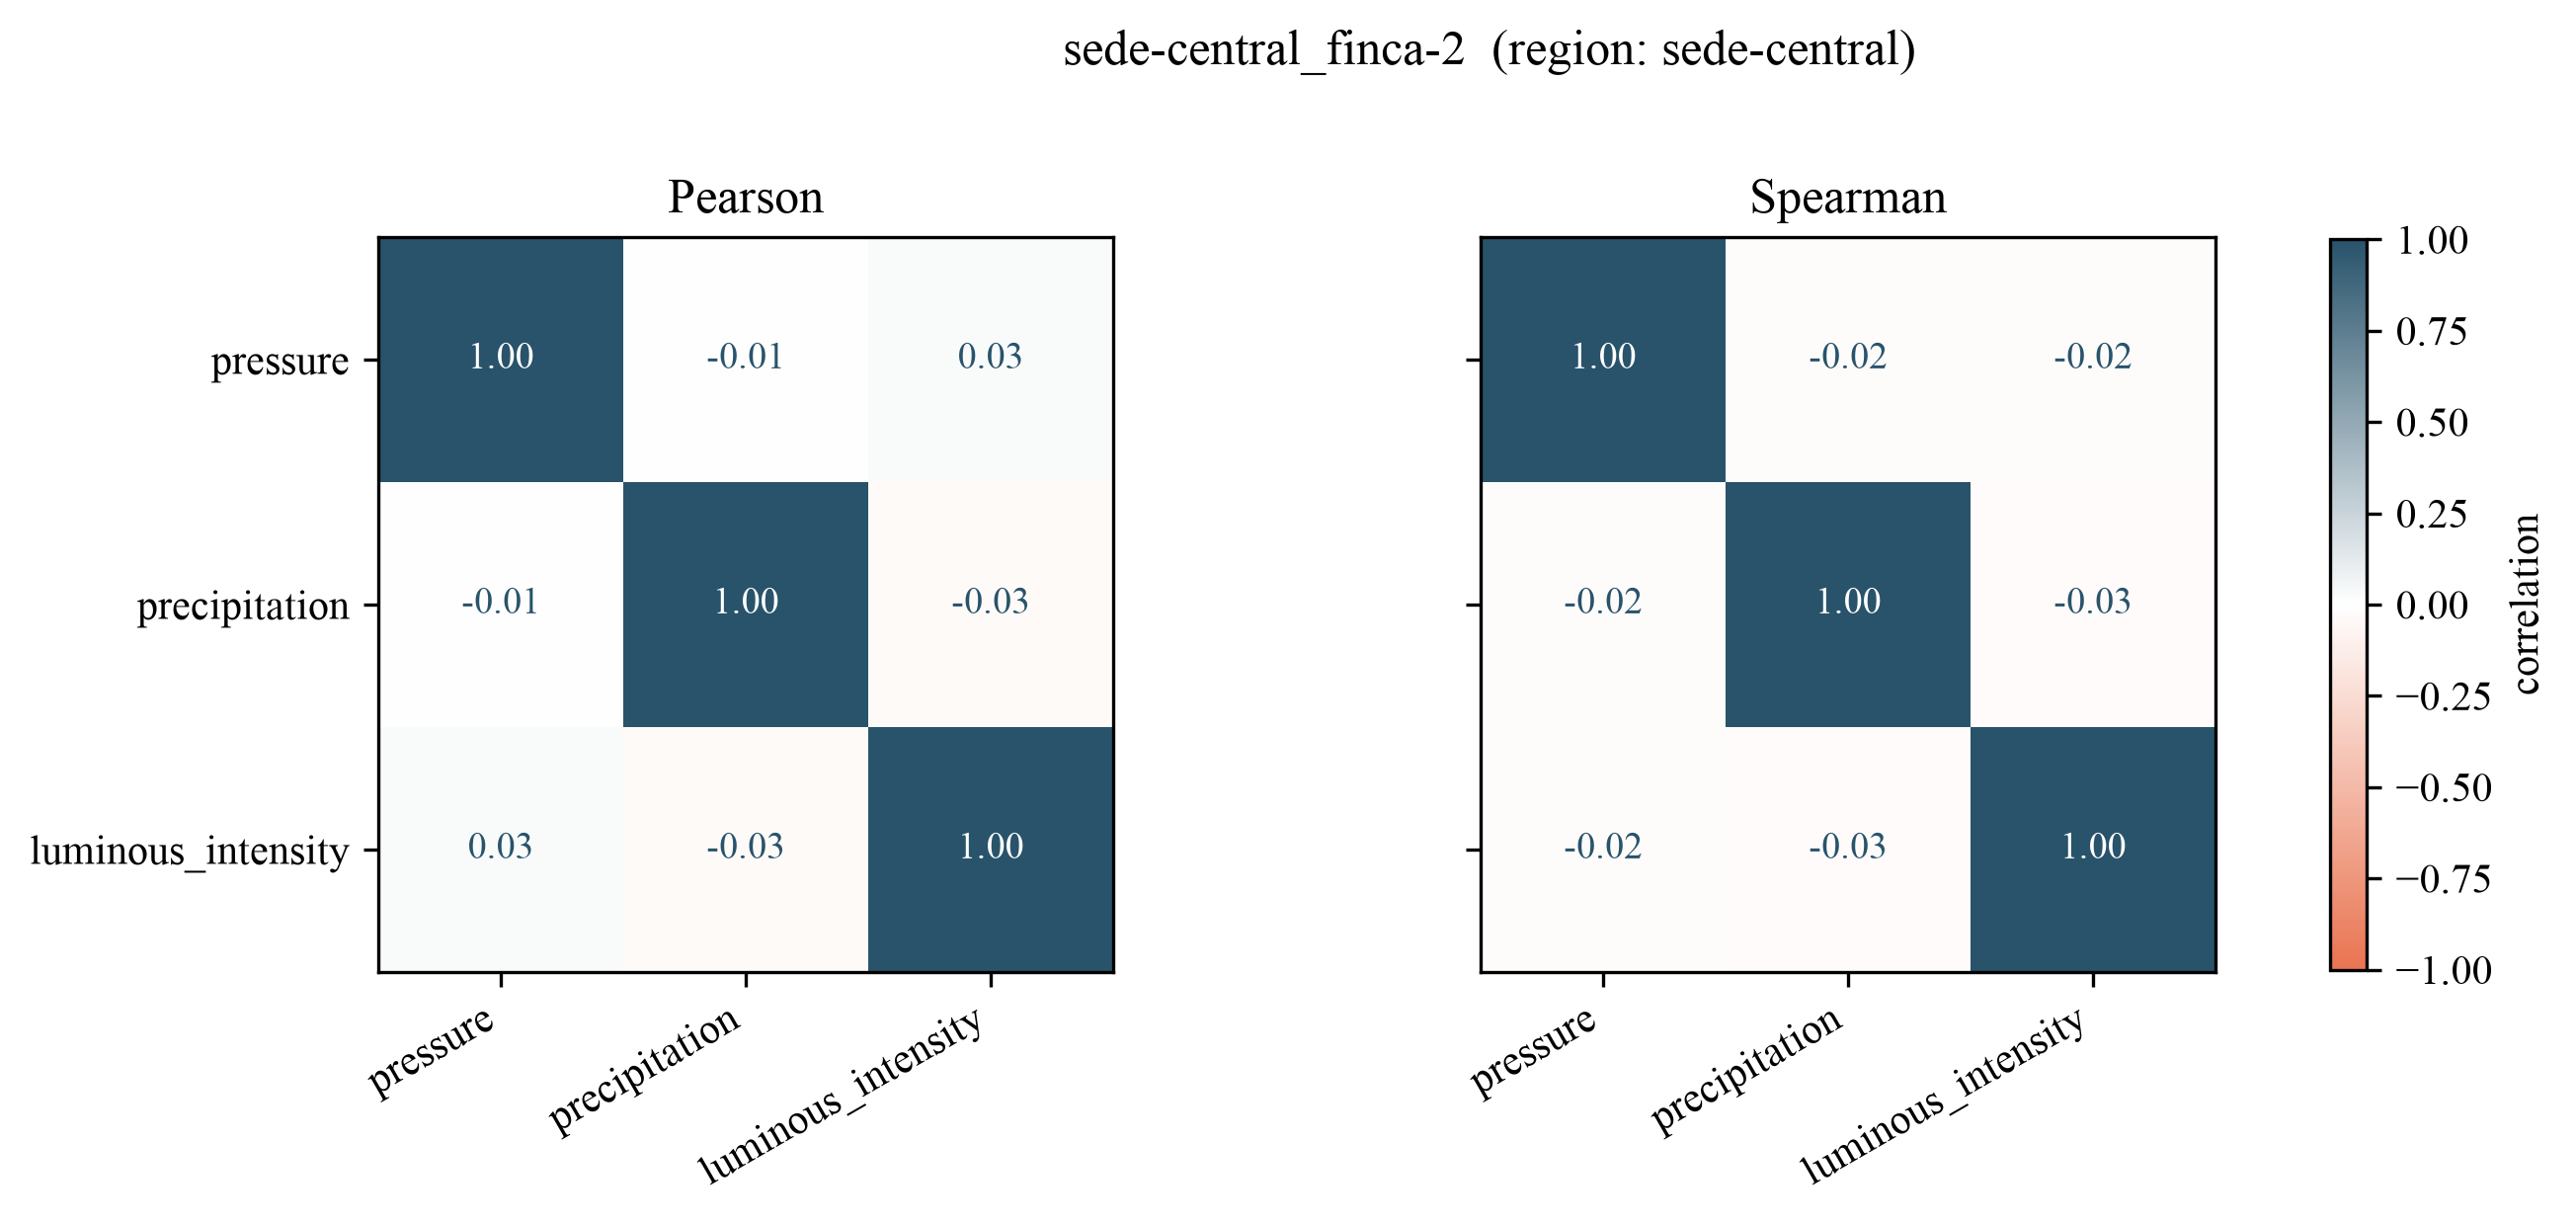

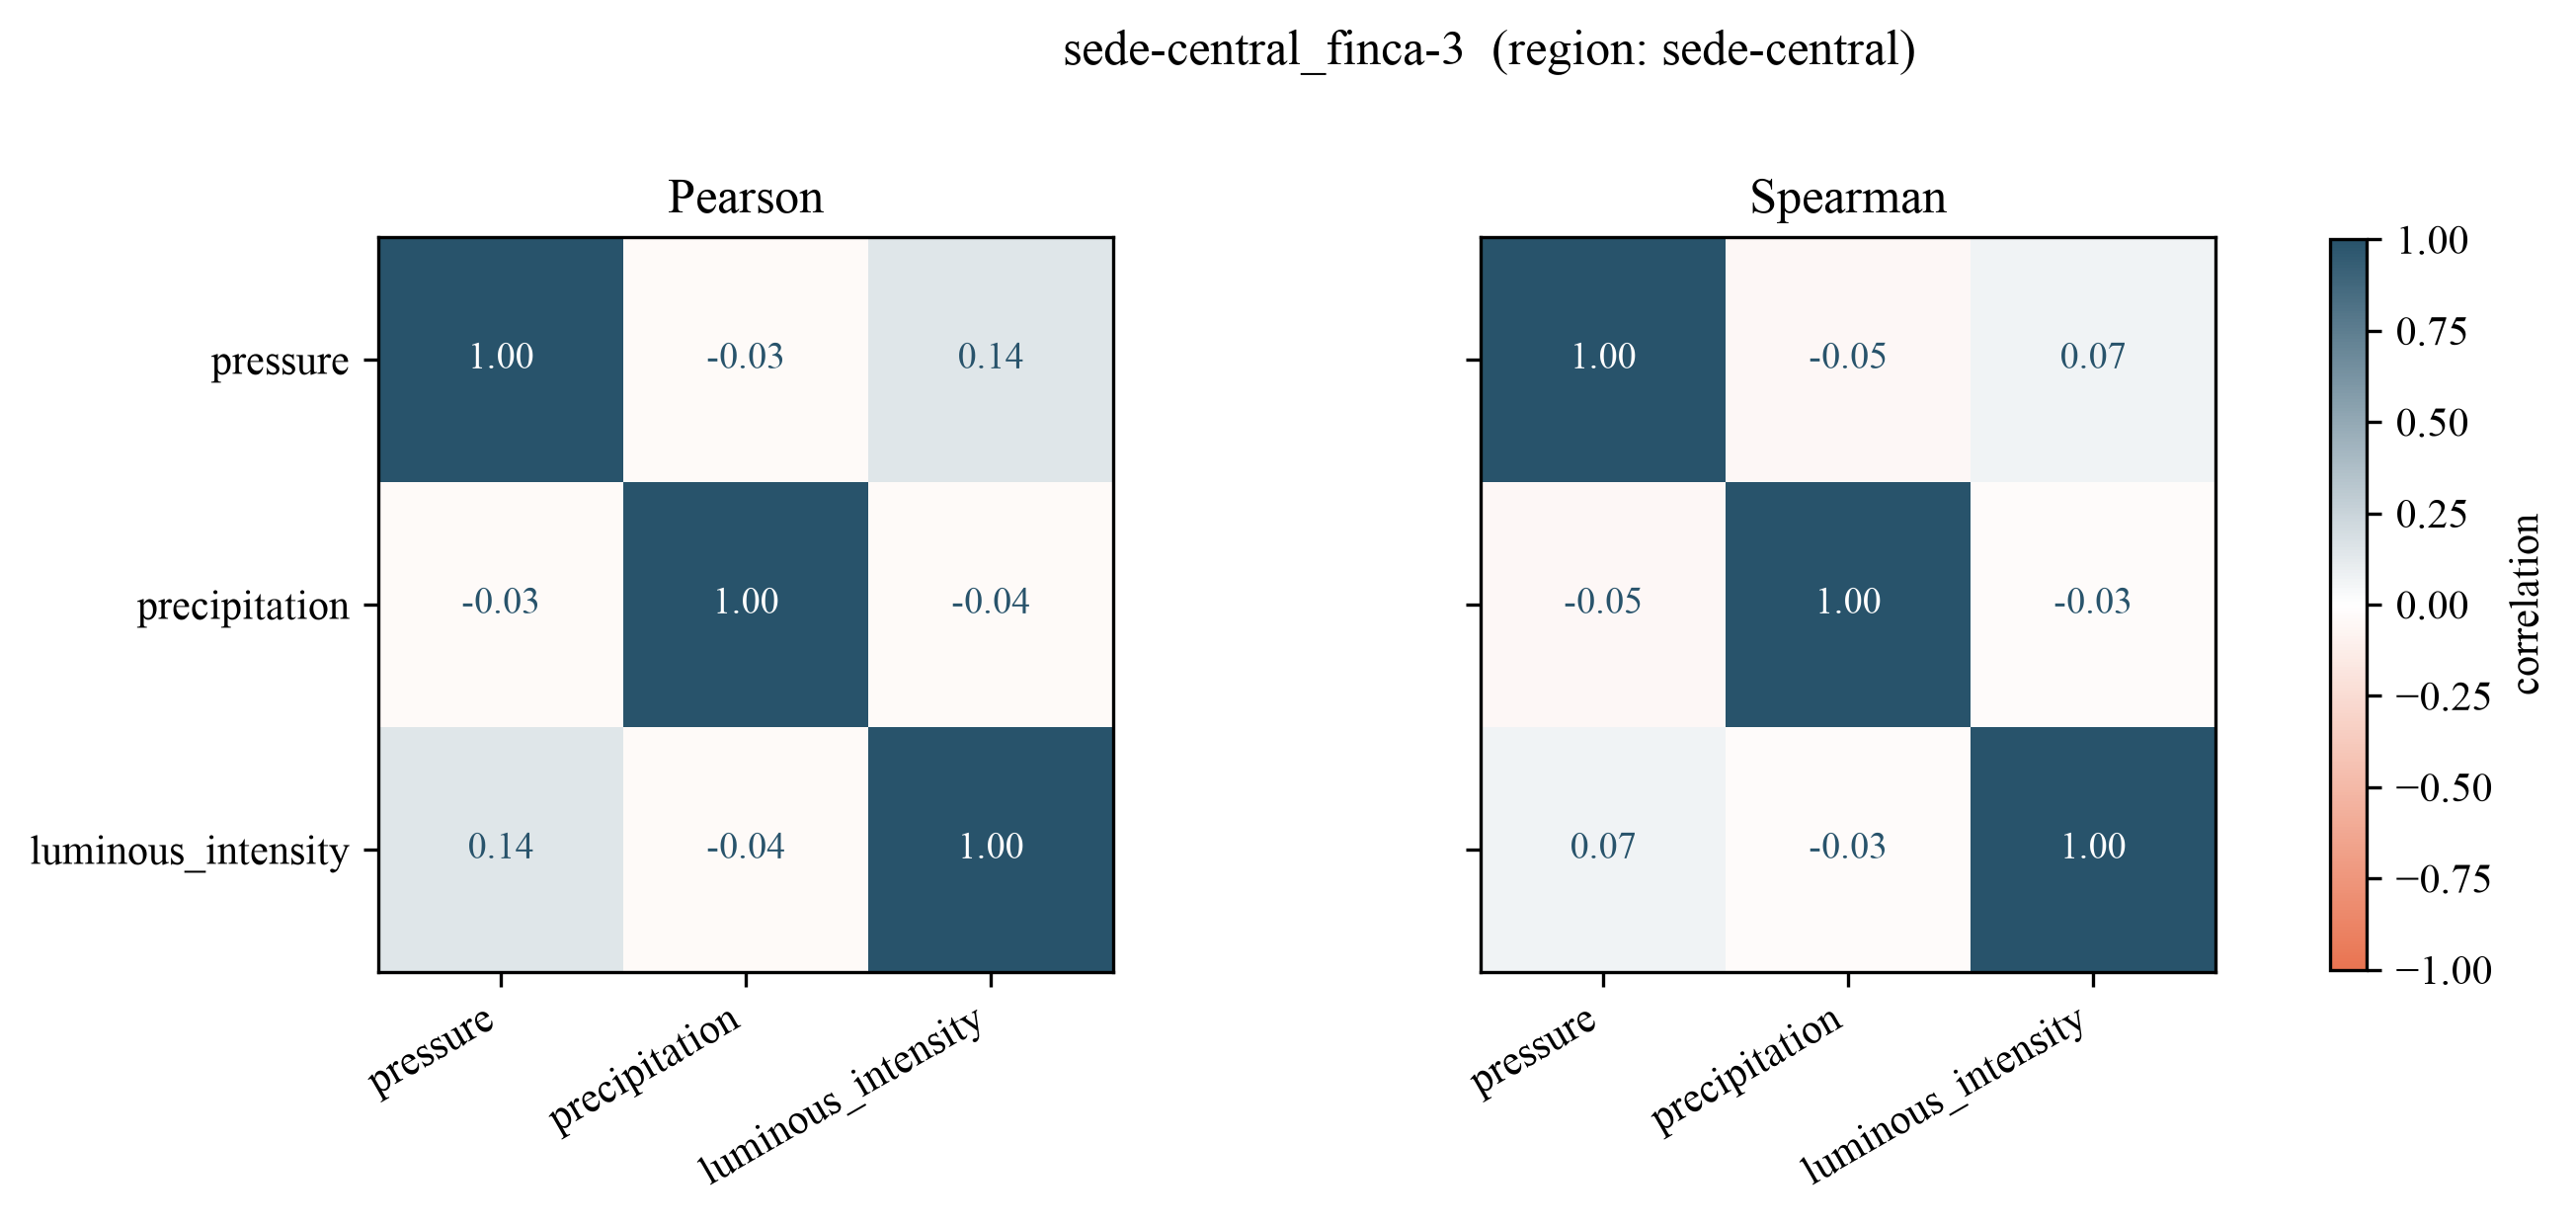

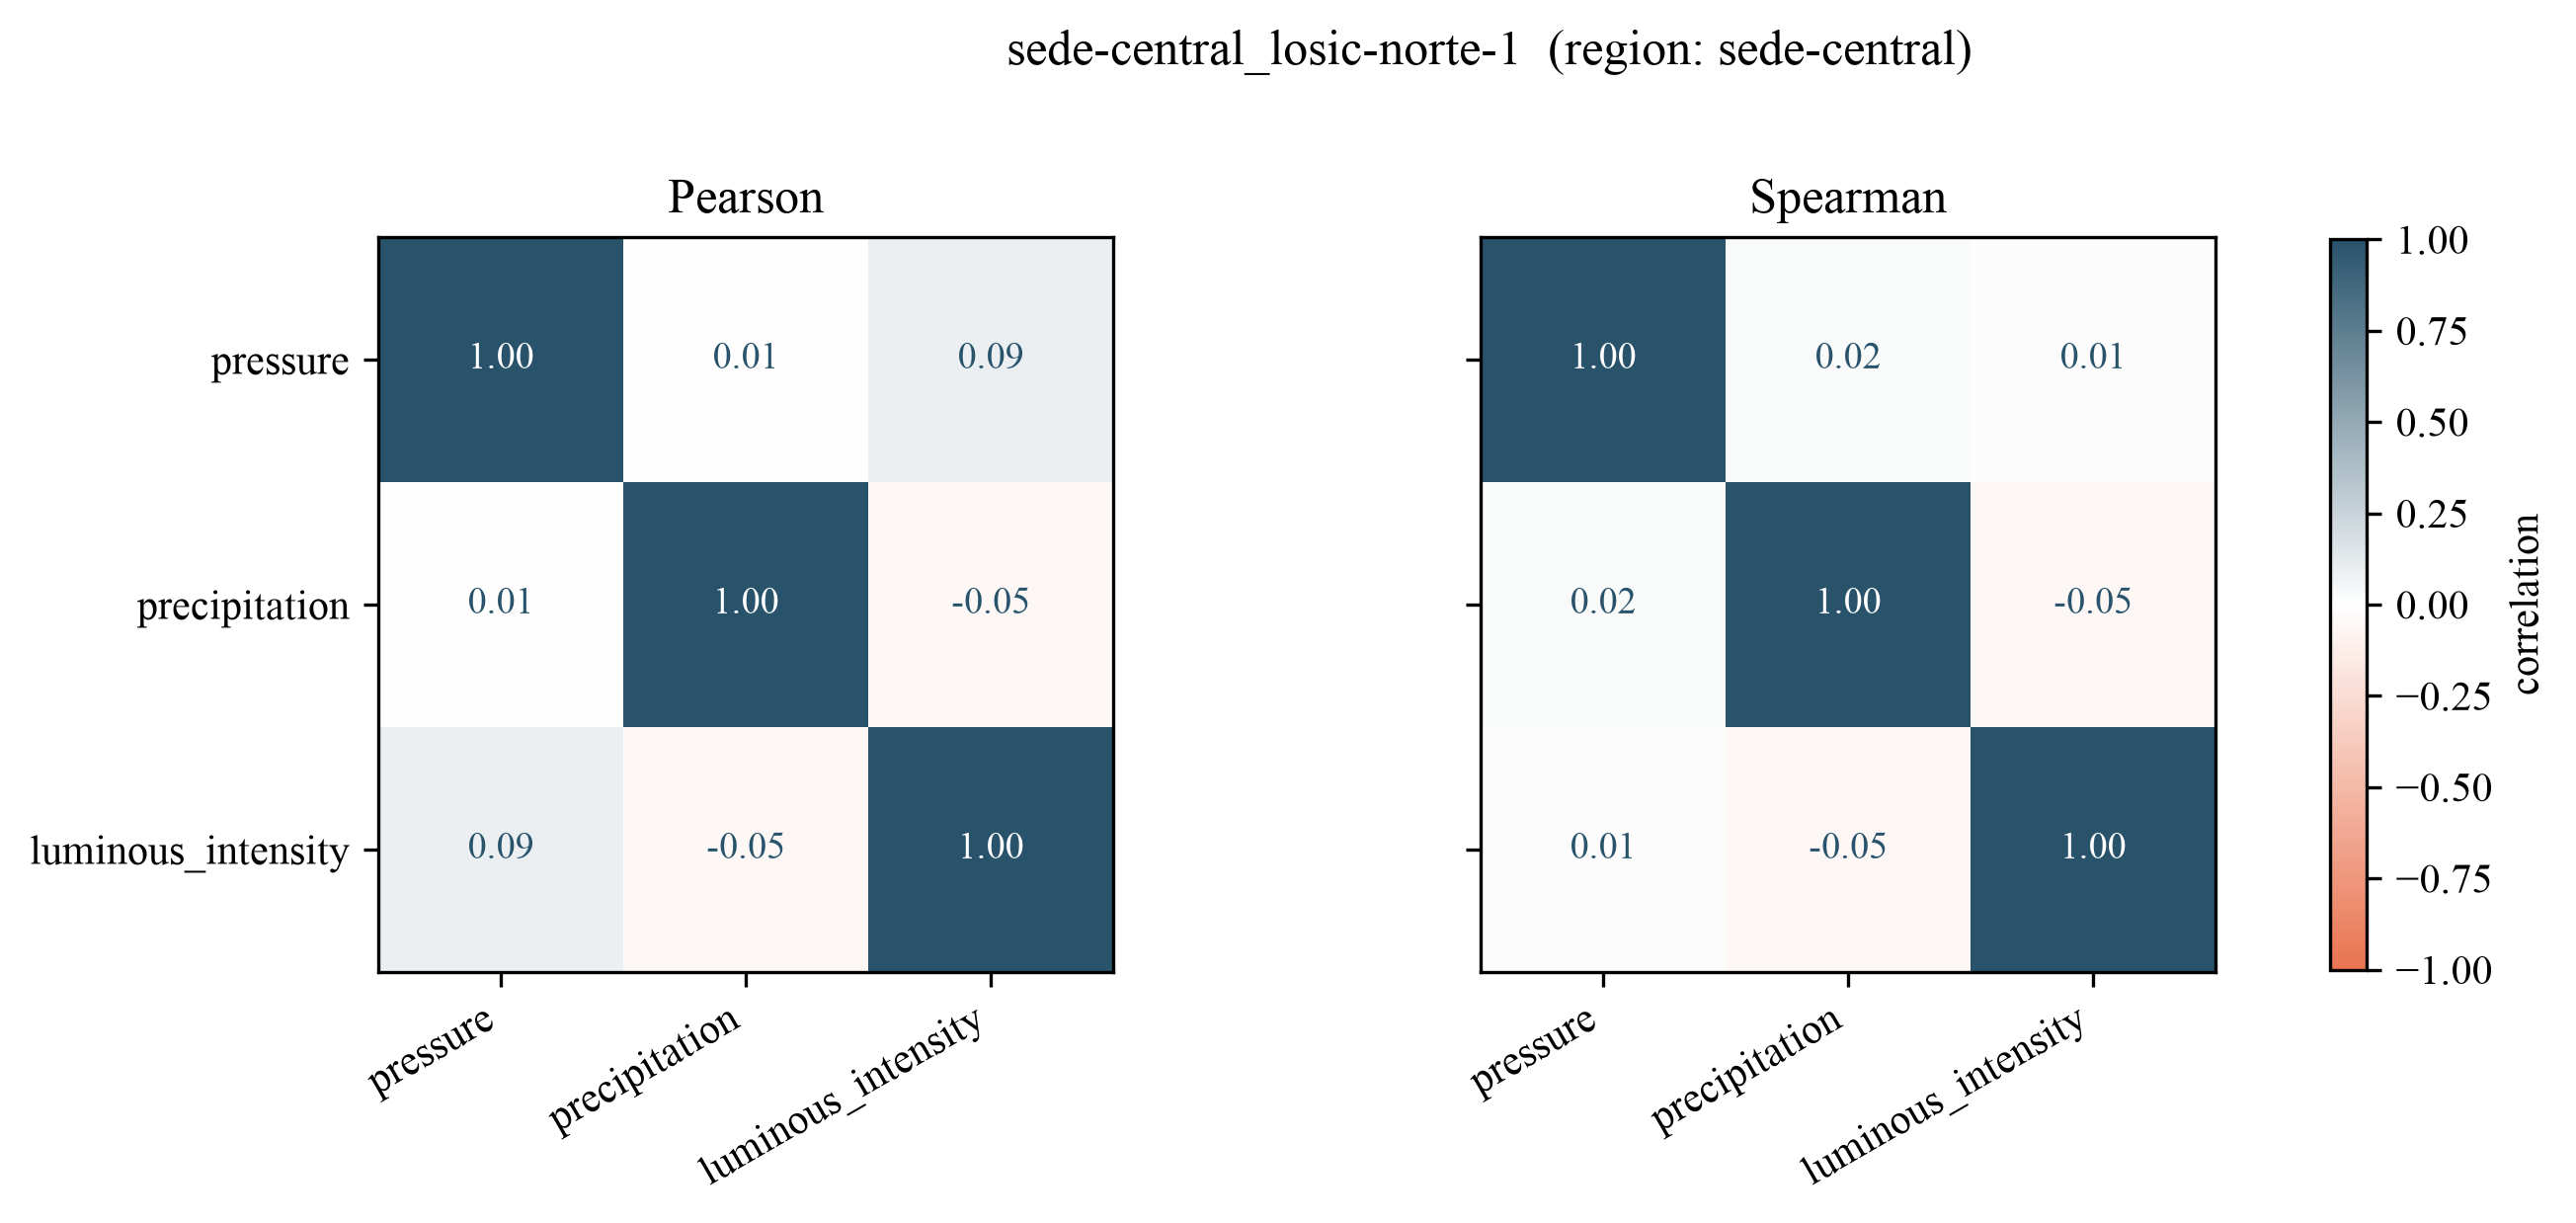

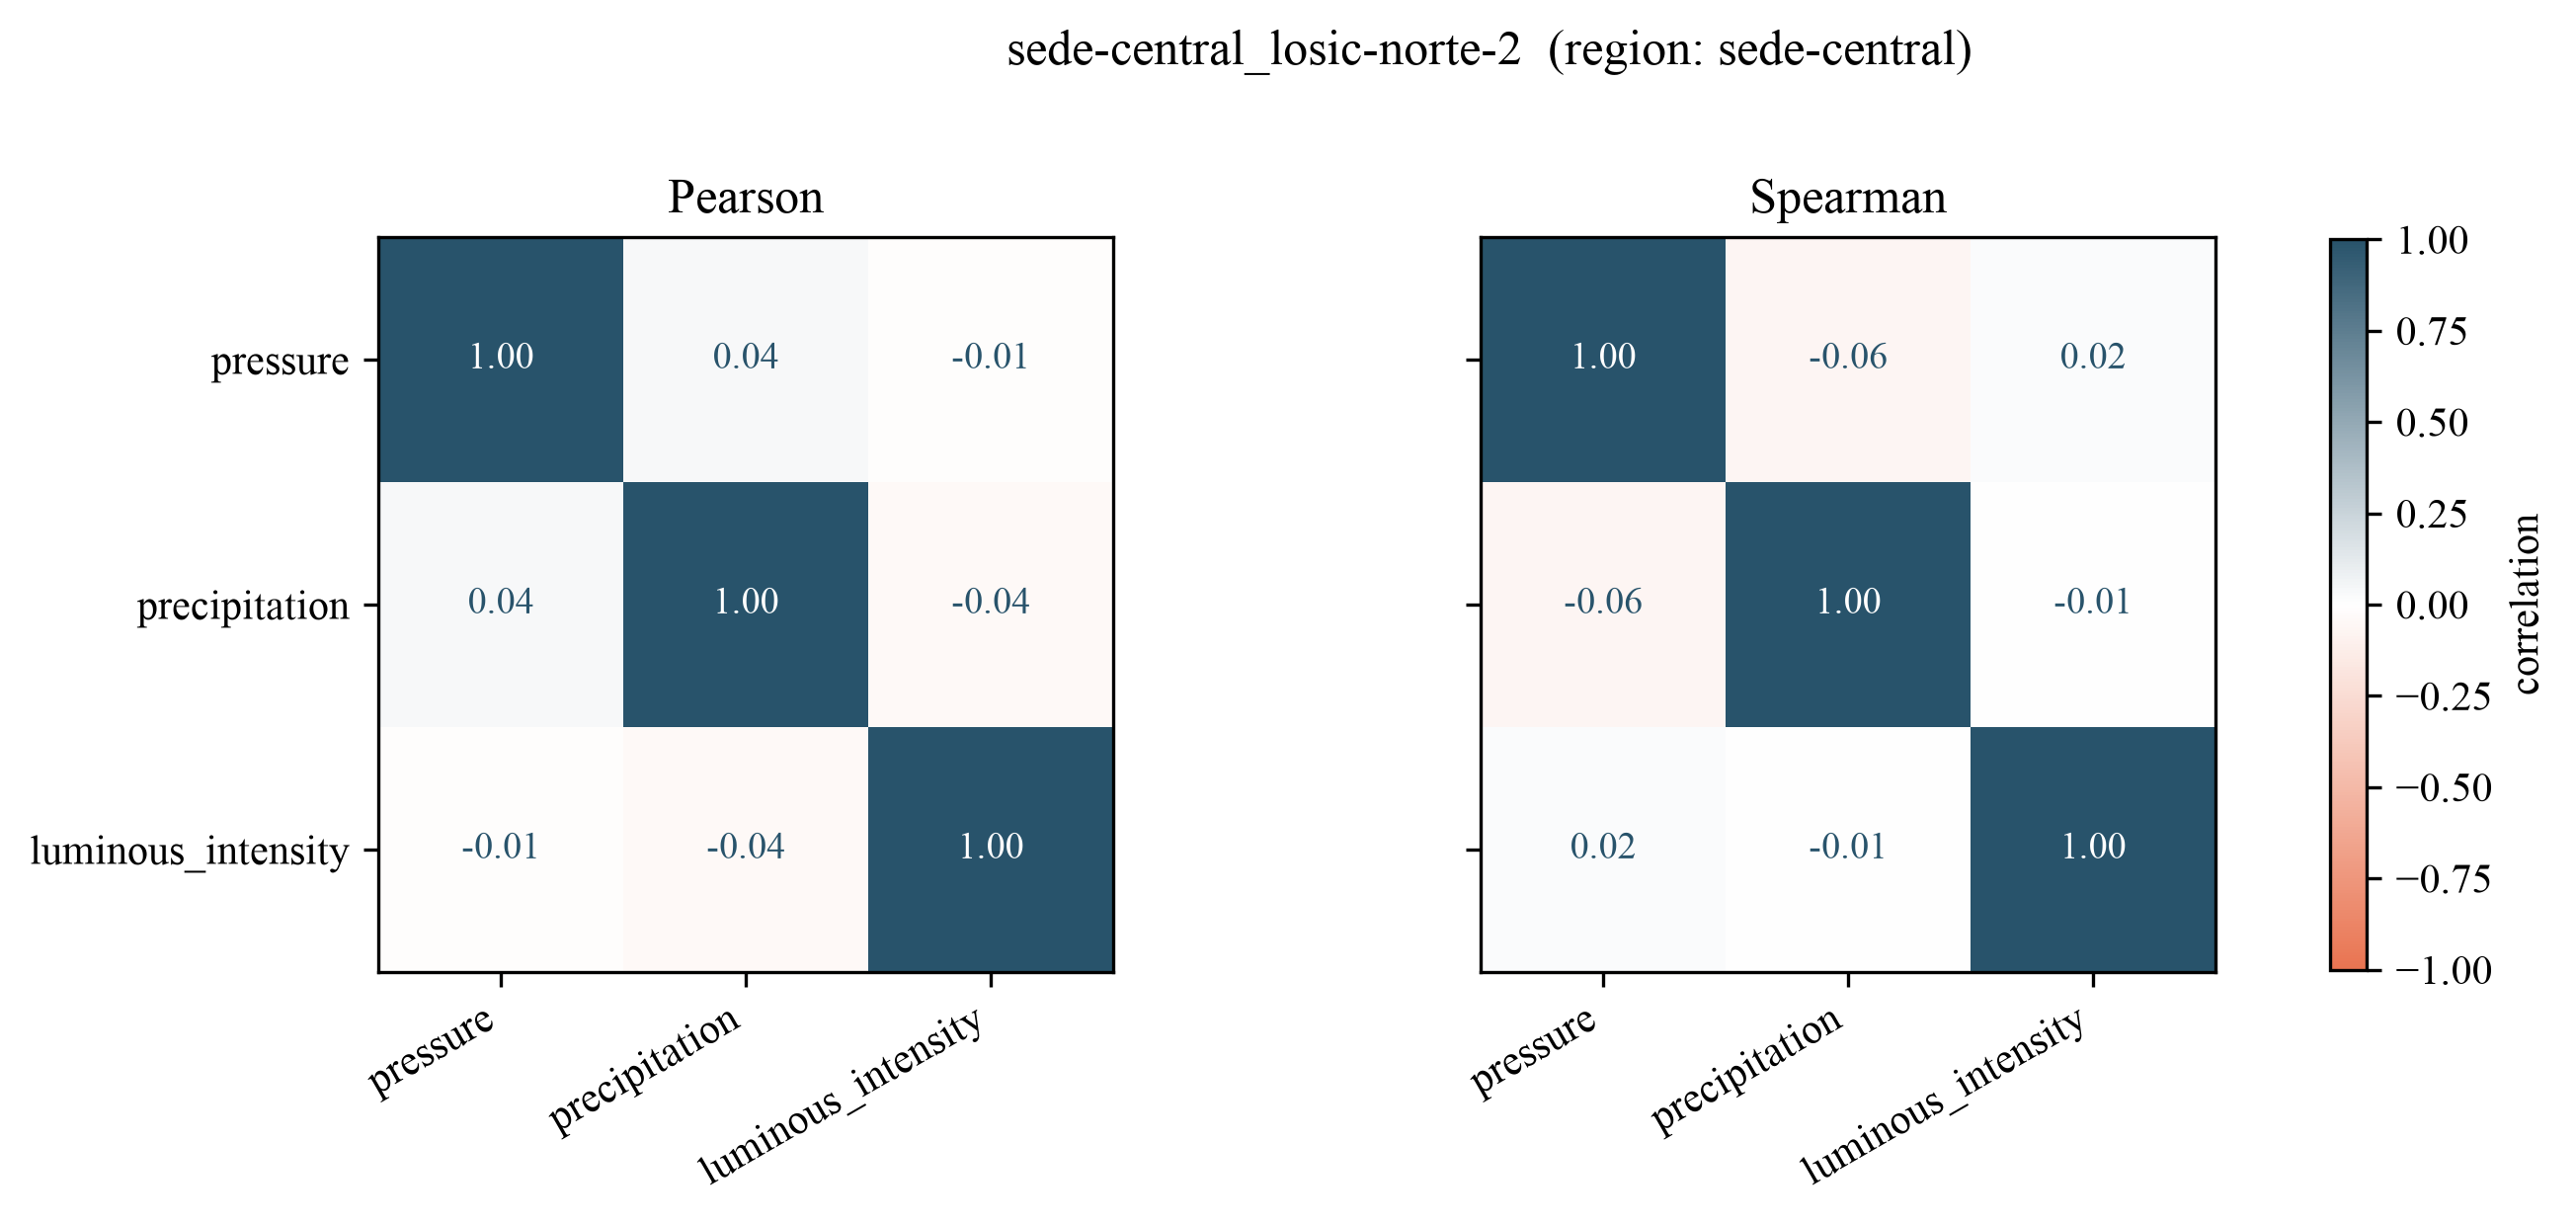

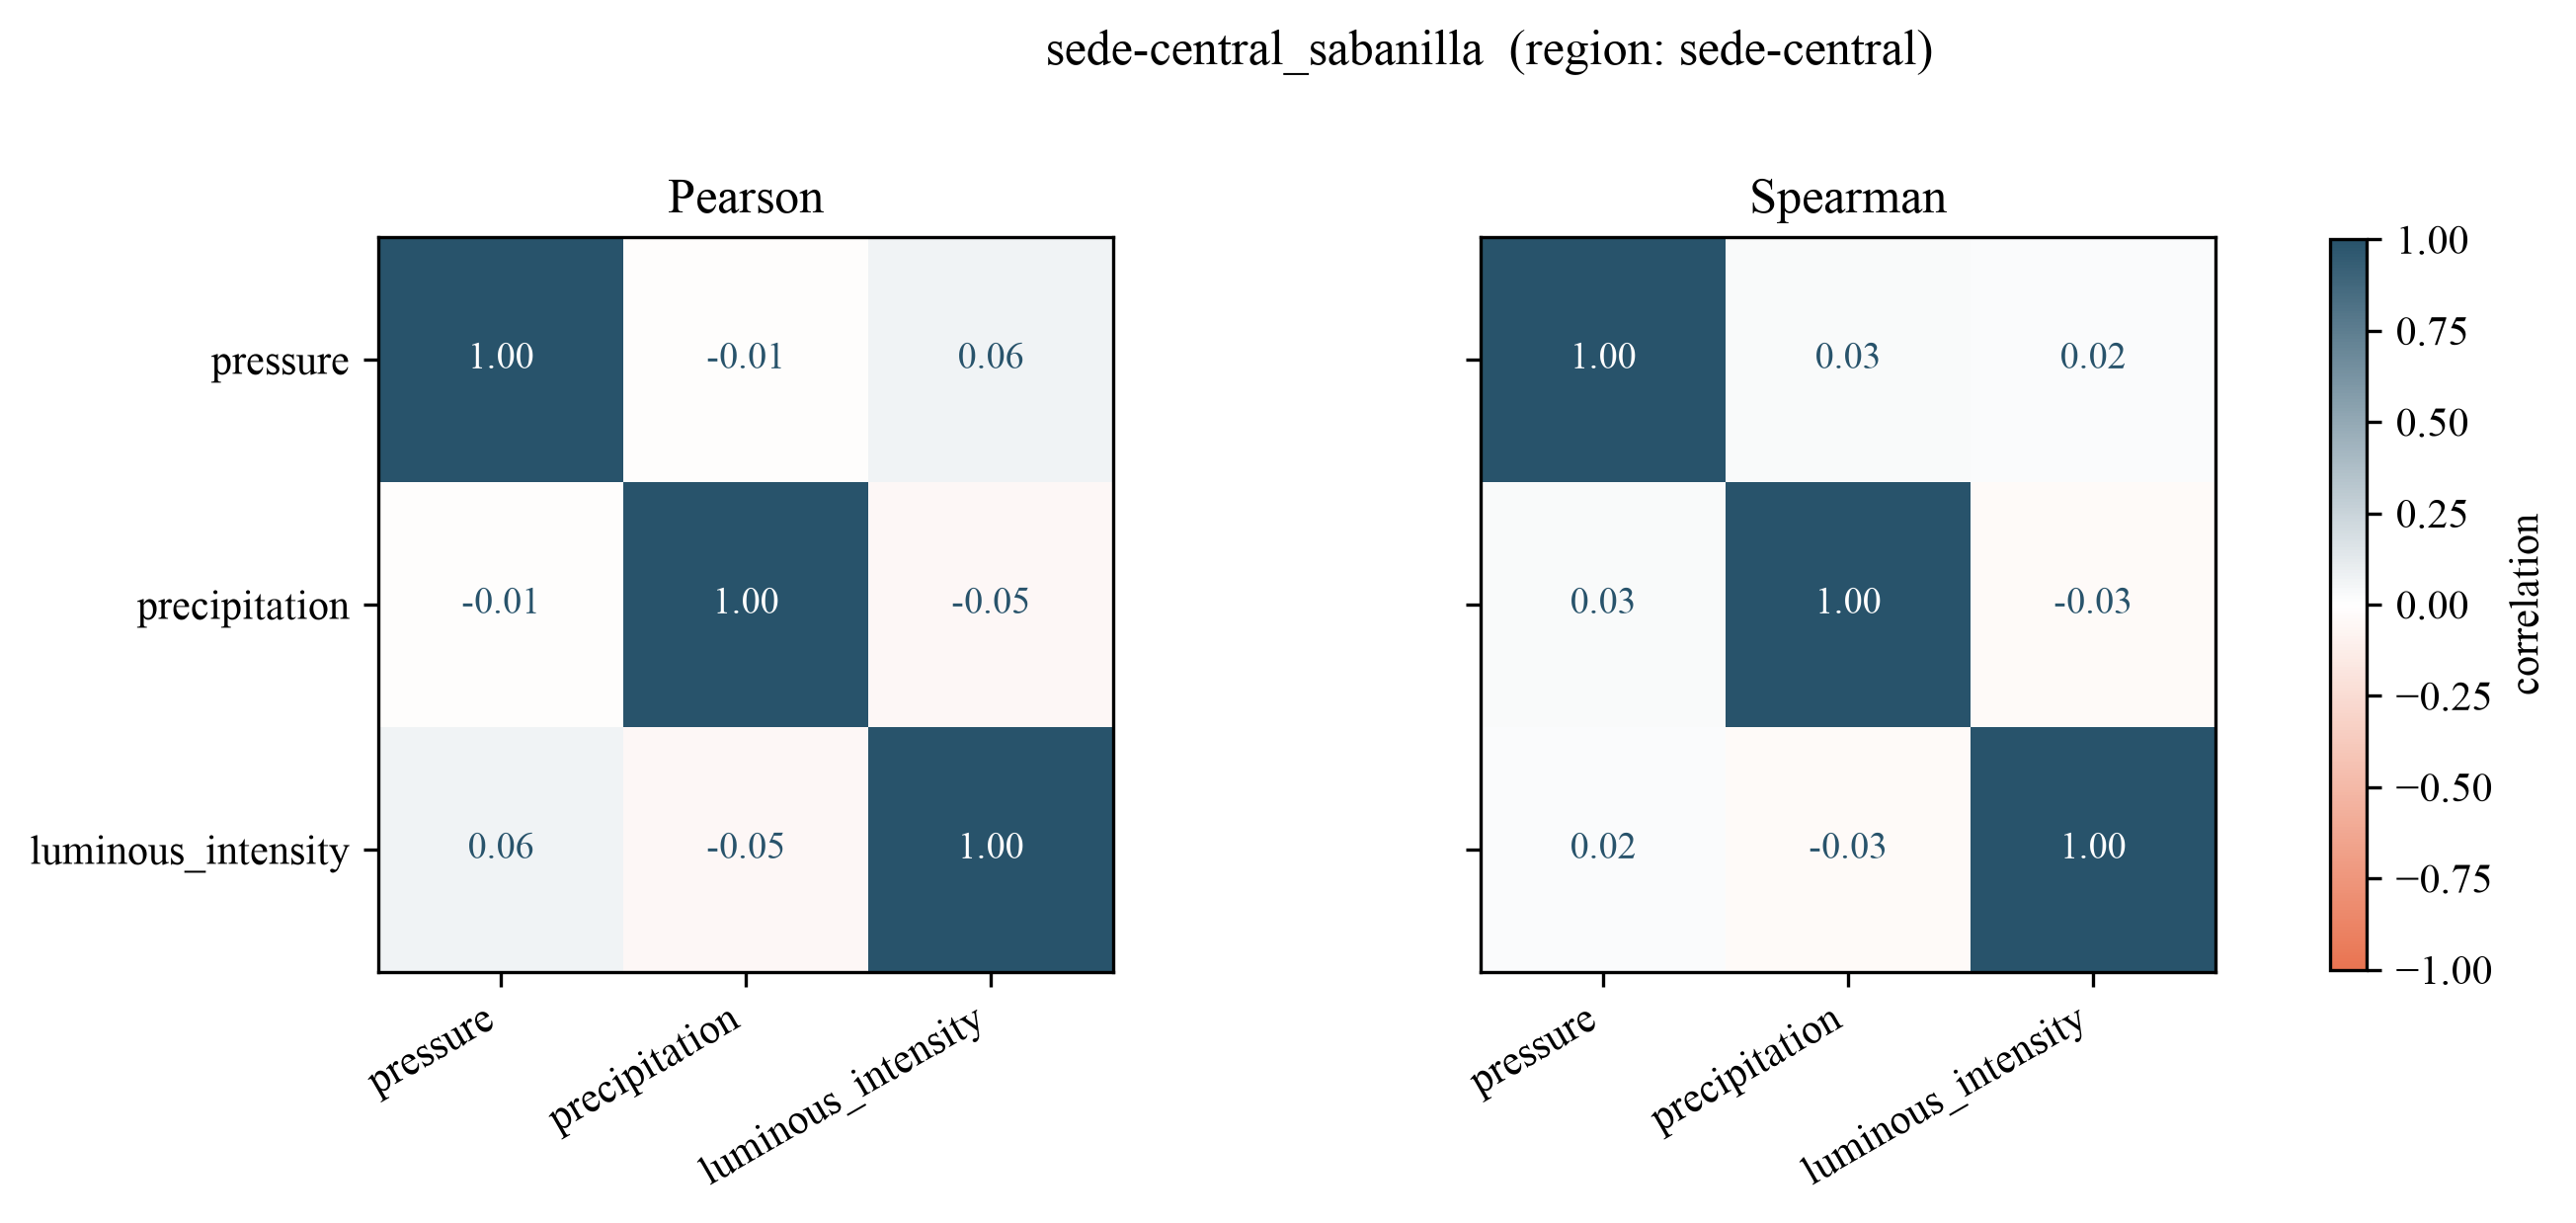

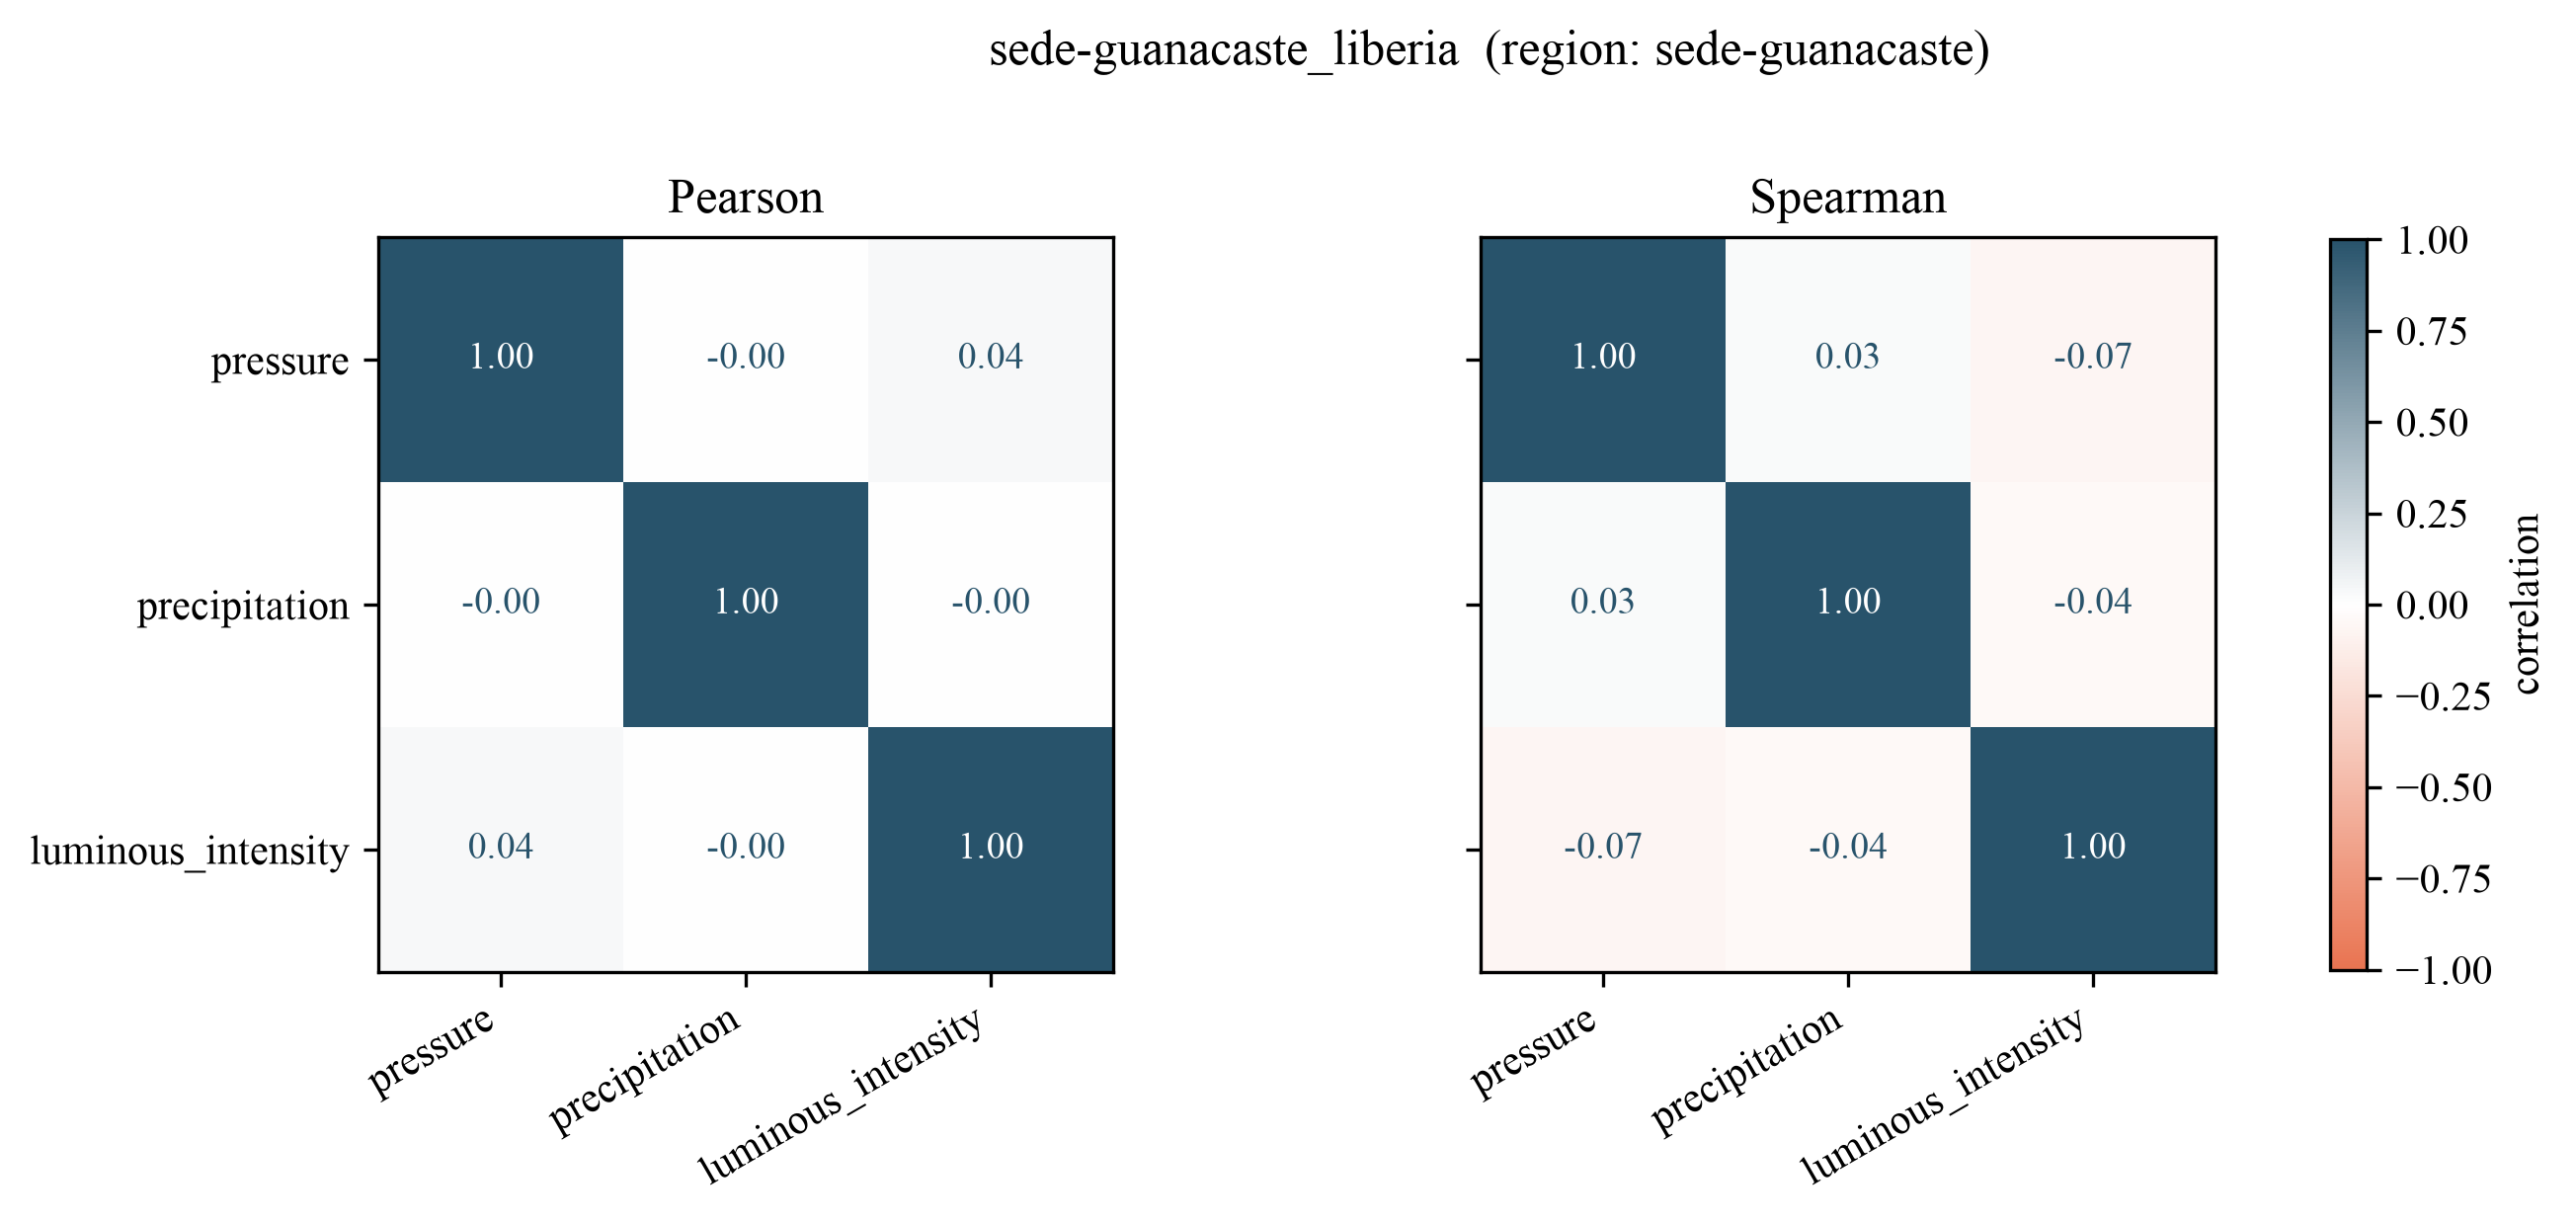

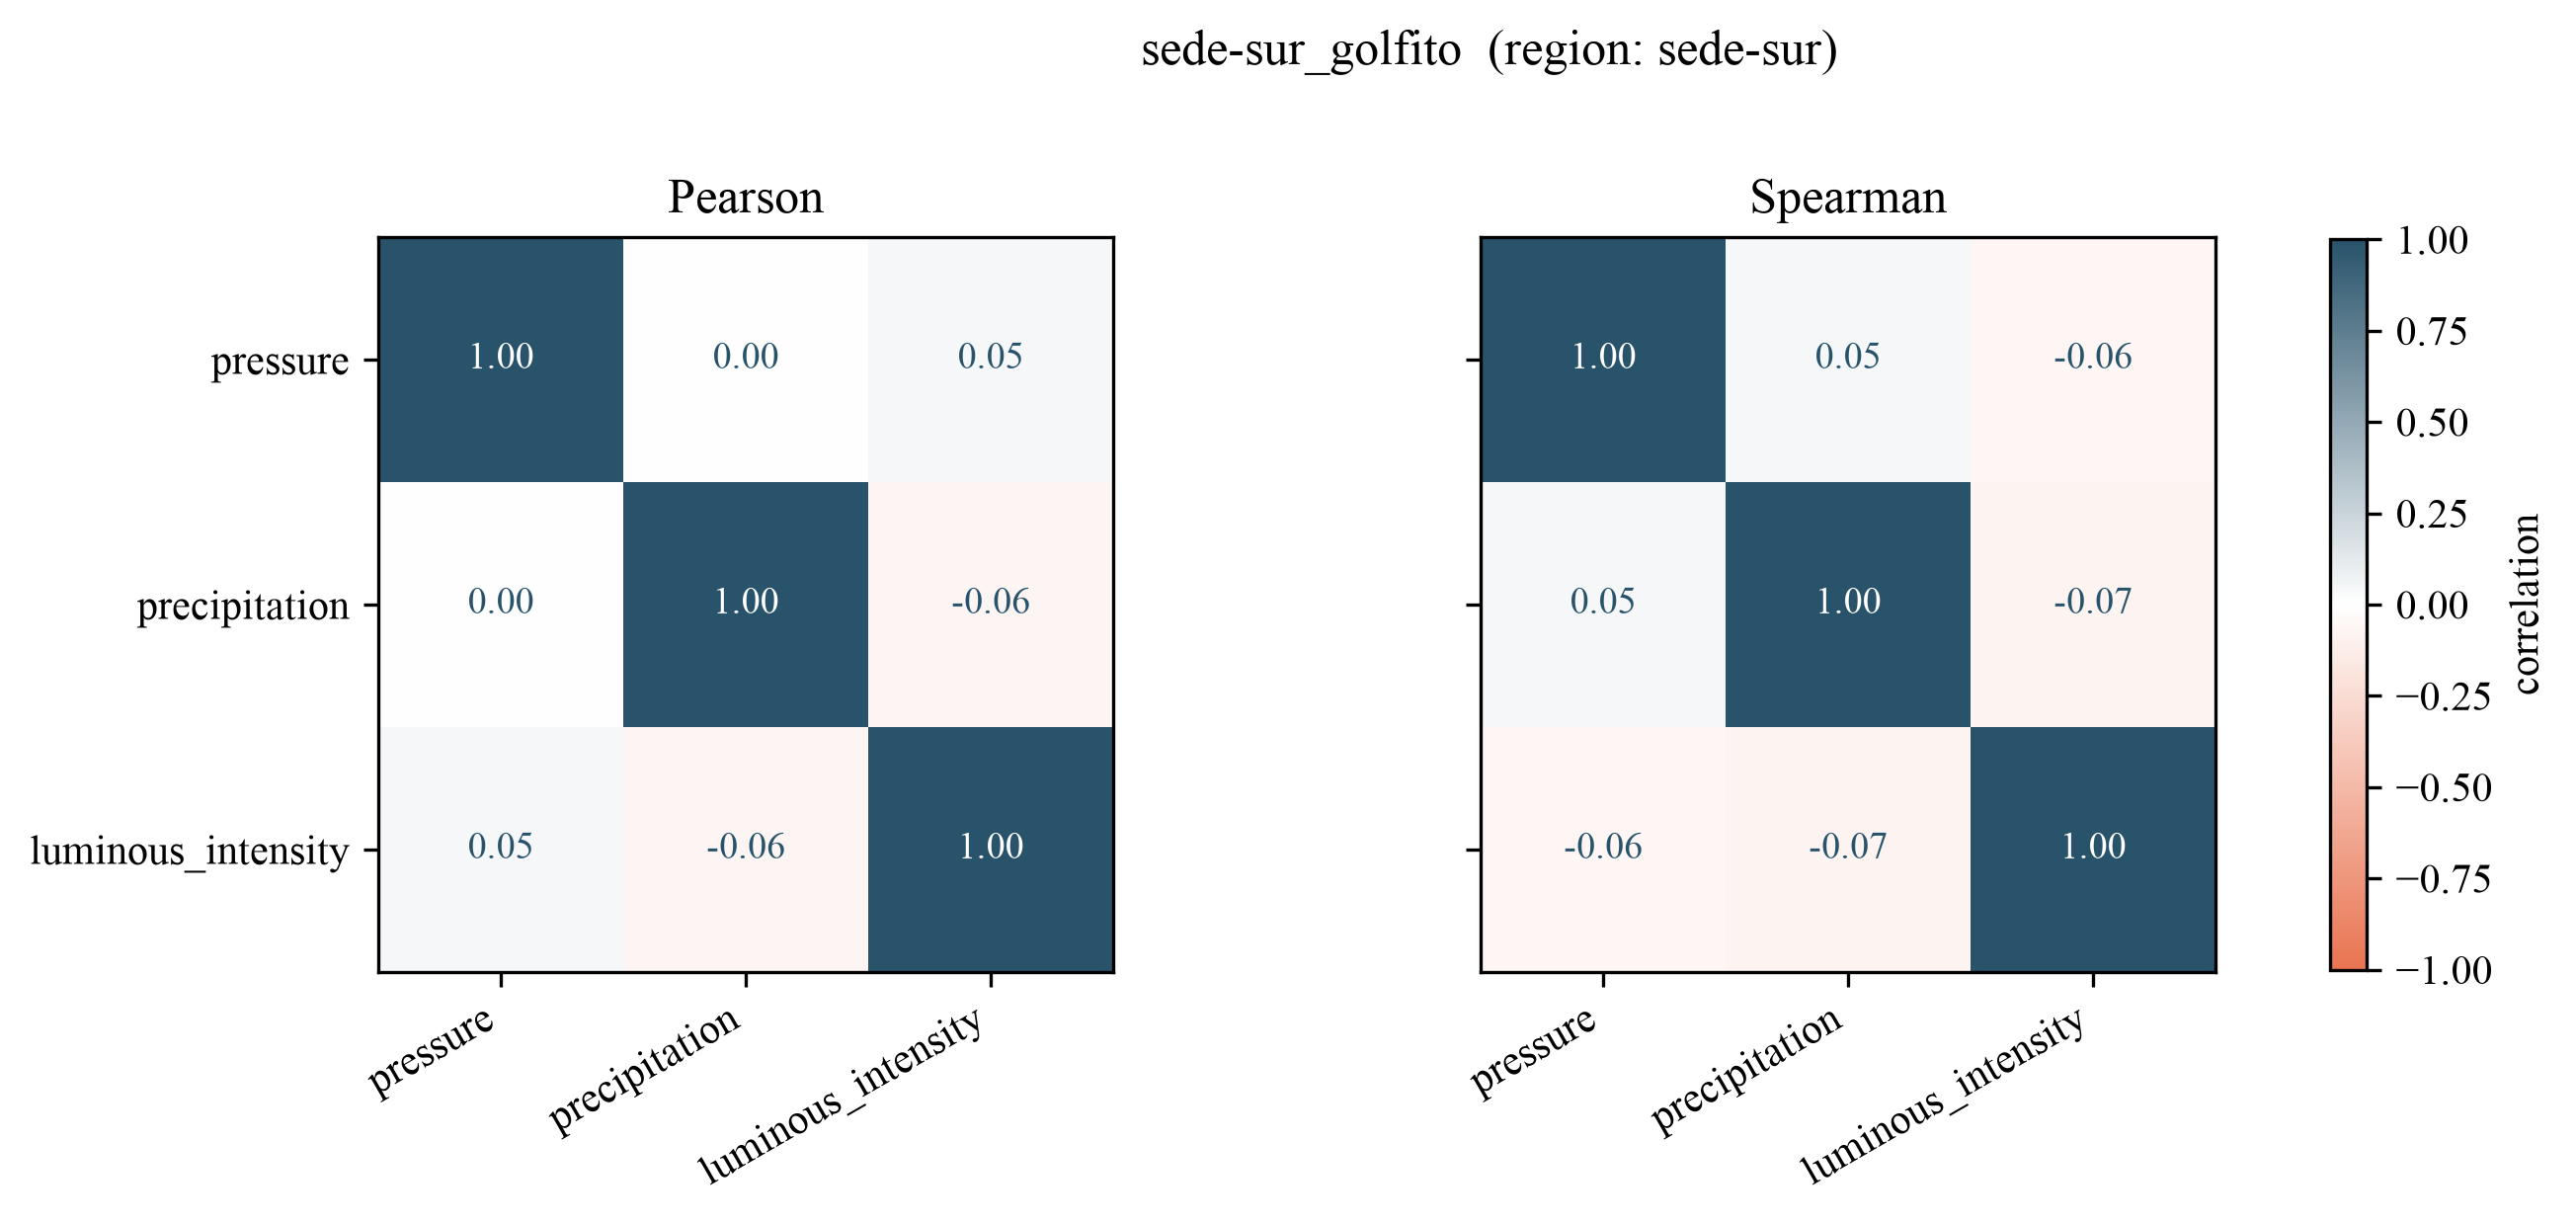

In [3]:
def plot_corr_heatmap(ax, matrix: pd.DataFrame, title: str, show_yticklabels: bool = True) -> None:
    im = ax.imshow(matrix.values, vmin=-1, vmax=1, cmap=DIVERGING_CMAP)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index if show_yticklabels else [])
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.values[i, j]
            text_color = "white" if abs(value) > 0.6 else PALETTE["indigo"]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=9)
    return im


station_corr: dict[str, dict[str, pd.DataFrame]] = {}
for station in STATIONS:
    corr = pairwise_correlation(station_data[station])
    station_corr[station] = corr
    corr["pearson"].to_csv(REPORT_DIR / f"{station}_pearson.csv")
    corr["spearman"].to_csv(REPORT_DIR / f"{station}_spearman.csv")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"wspace": 0.5})
    im = plot_corr_heatmap(axes[0], corr["pearson"], "Pearson")
    plot_corr_heatmap(axes[1], corr["spearman"], "Spearman", show_yticklabels=False)
    fig.suptitle(f"{station}  (region: {REGION[station]})")
    fig.colorbar(im, ax=axes, shrink=0.8, label="correlation")
    fig.savefig(REPORT_DIR / f"{station}_correlation_heatmap.png", bbox_inches="tight")
    plt.show()


Region labels (from `REGION`/`scope` above) are shown on each heatmap for
context, not used as a grouping key -- matrices are computed per station and
deliberately not pooled into one "average station," whether or not any
in-scope stations happen to share a region prefix; a shared relationship
across stations would be a finding, not an assumption.


In [4]:
summary_rows = []
for station in STATIONS:
    for var1, var2 in PAIRS:
        method = primary_method(var1, var2)
        value = station_corr[station][method].loc[var1, var2]
        summary_rows.append(
            {"station": station, "region": REGION[station], "pair": f"{var1}-{var2}", "method": method, "correlation": value}
        )
summary = pd.DataFrame(summary_rows)
summary.to_csv(REPORT_DIR / "primary_correlation_summary.csv", index=False)
summary.pivot(index="station", columns="pair", values="correlation")


pair,precipitation-luminous_intensity,pressure-luminous_intensity,pressure-precipitation
station,,,
recinto-esparza,-0.028843,-0.010485,0.029825
recinto-santa-cruz,0.001314,-0.042464,0.026668
sede-atlantico_turrialba,-0.063365,0.036496,0.029820
sede-central_finca-1,-0.009484,-0.102994,-0.003229
sede-central_finca-2,-0.025502,0.025768,-0.017979
sede-central_finca-3,-0.026784,0.144289,-0.050405
sede-central_losic-norte-1,-0.050963,0.089918,0.023449
sede-central_losic-norte-2,-0.007136,-0.009386,-0.064174
sede-central_sabanilla,-0.031831,0.063815,0.029077


## Cross-correlation (CCF)

For each station × sensor pair, correlation across a +-6h lag window
(36 steps of the 10-minute grid) — reveals whether one sensor's change leads
or lags the other's rather than assuming a purely simultaneous relationship.
Positive lag: the second-named variable's later values line up with the
first's current ones (see `uema.correlation.ccf` docstring for the exact
convention).


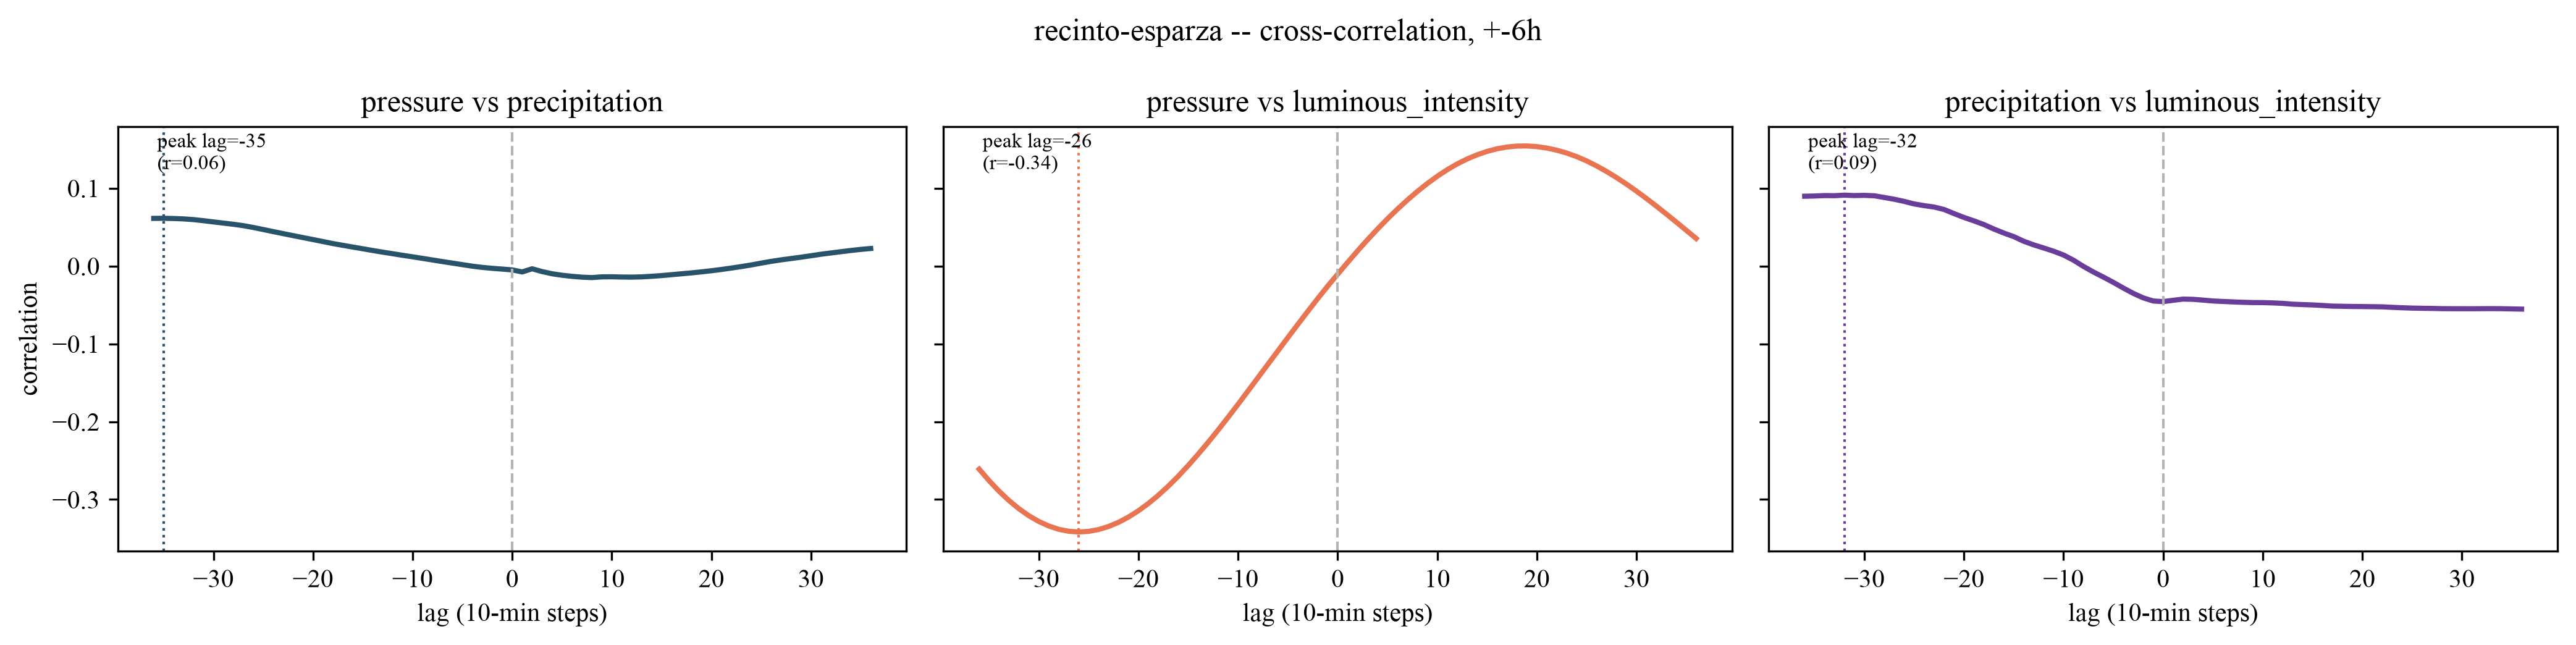

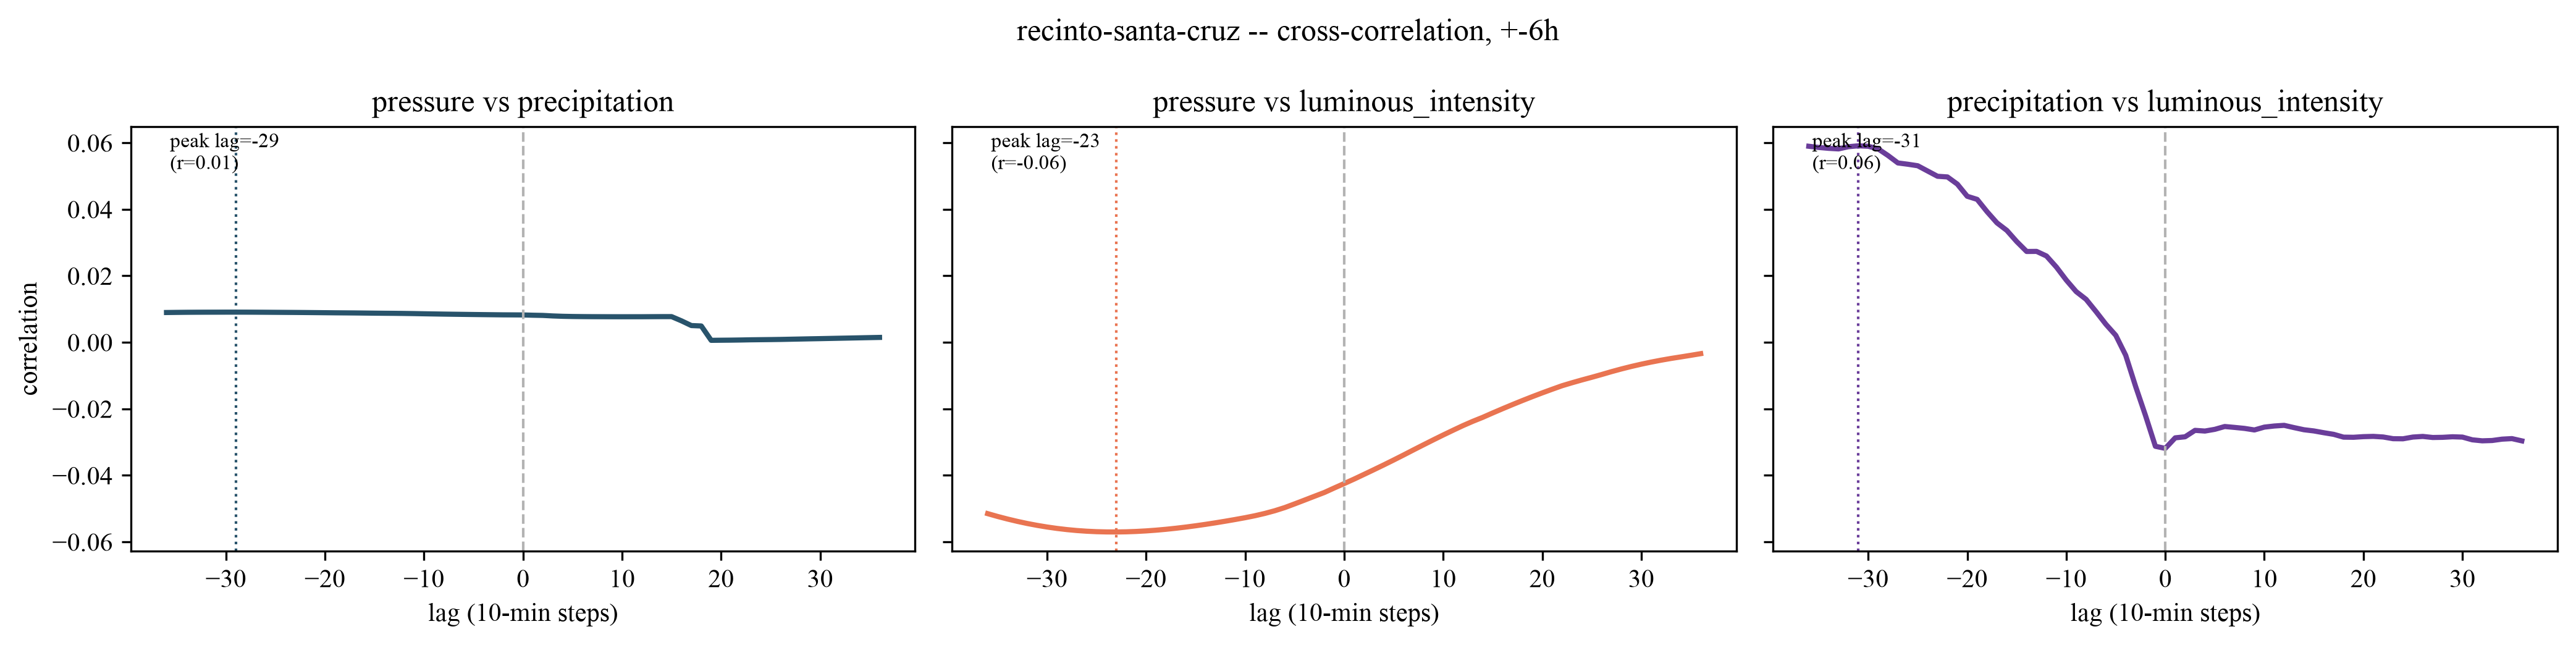

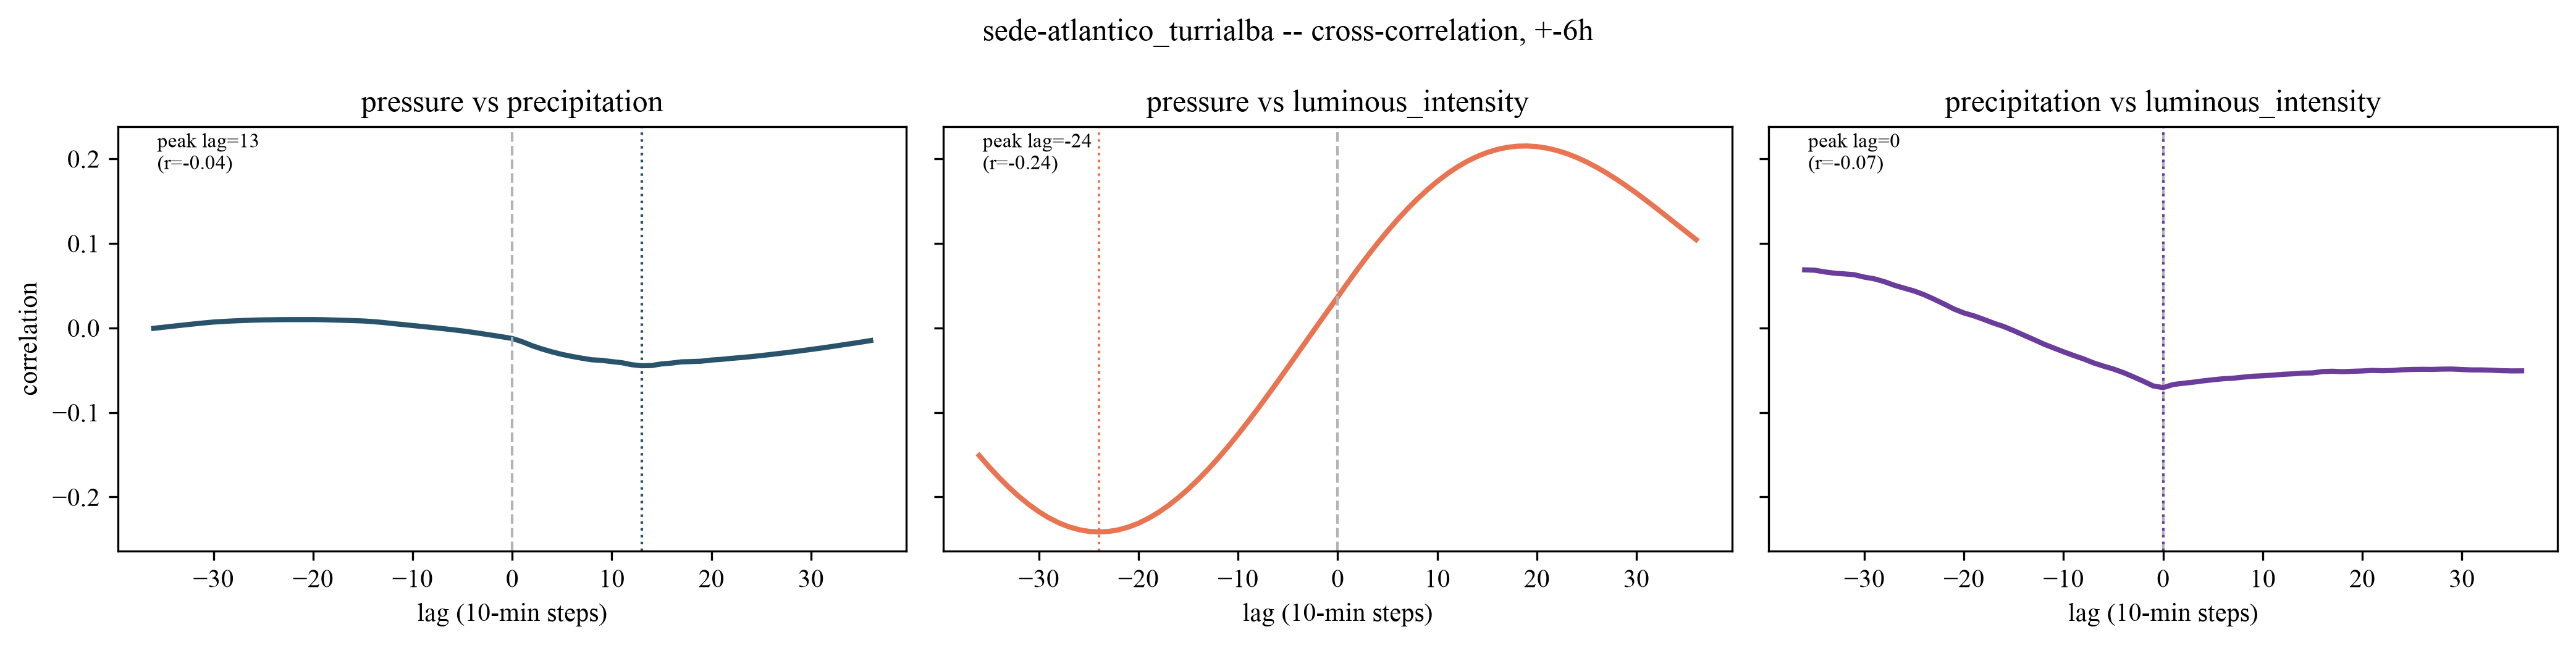

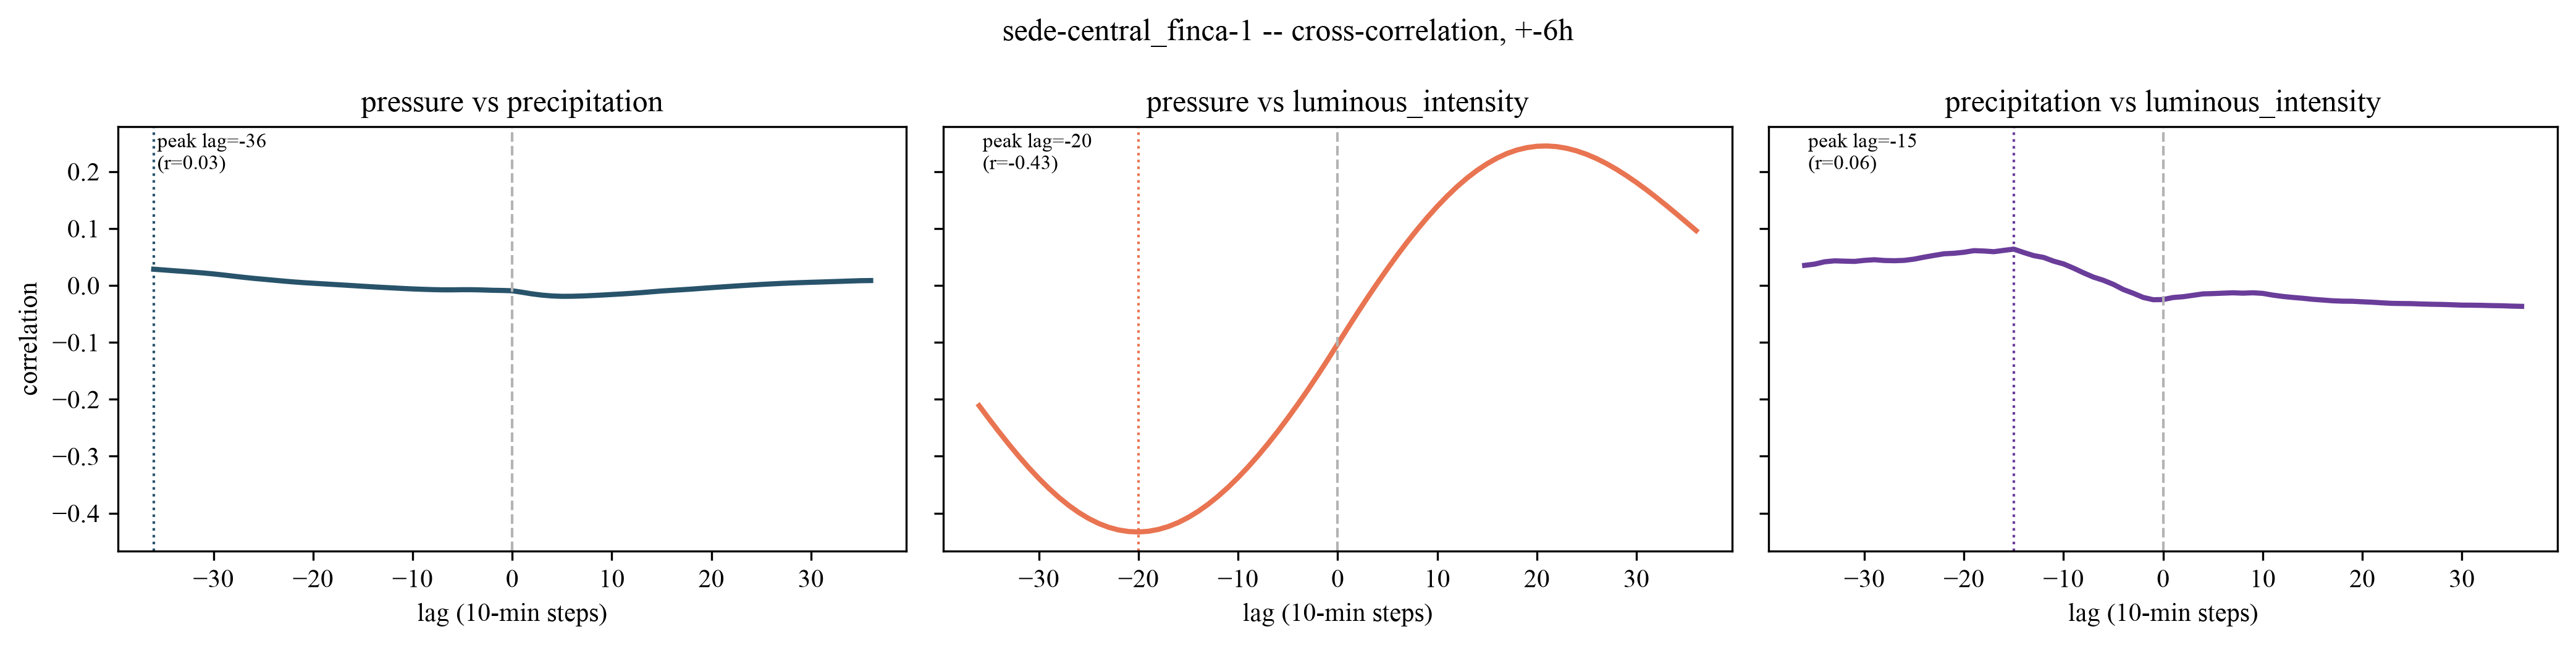

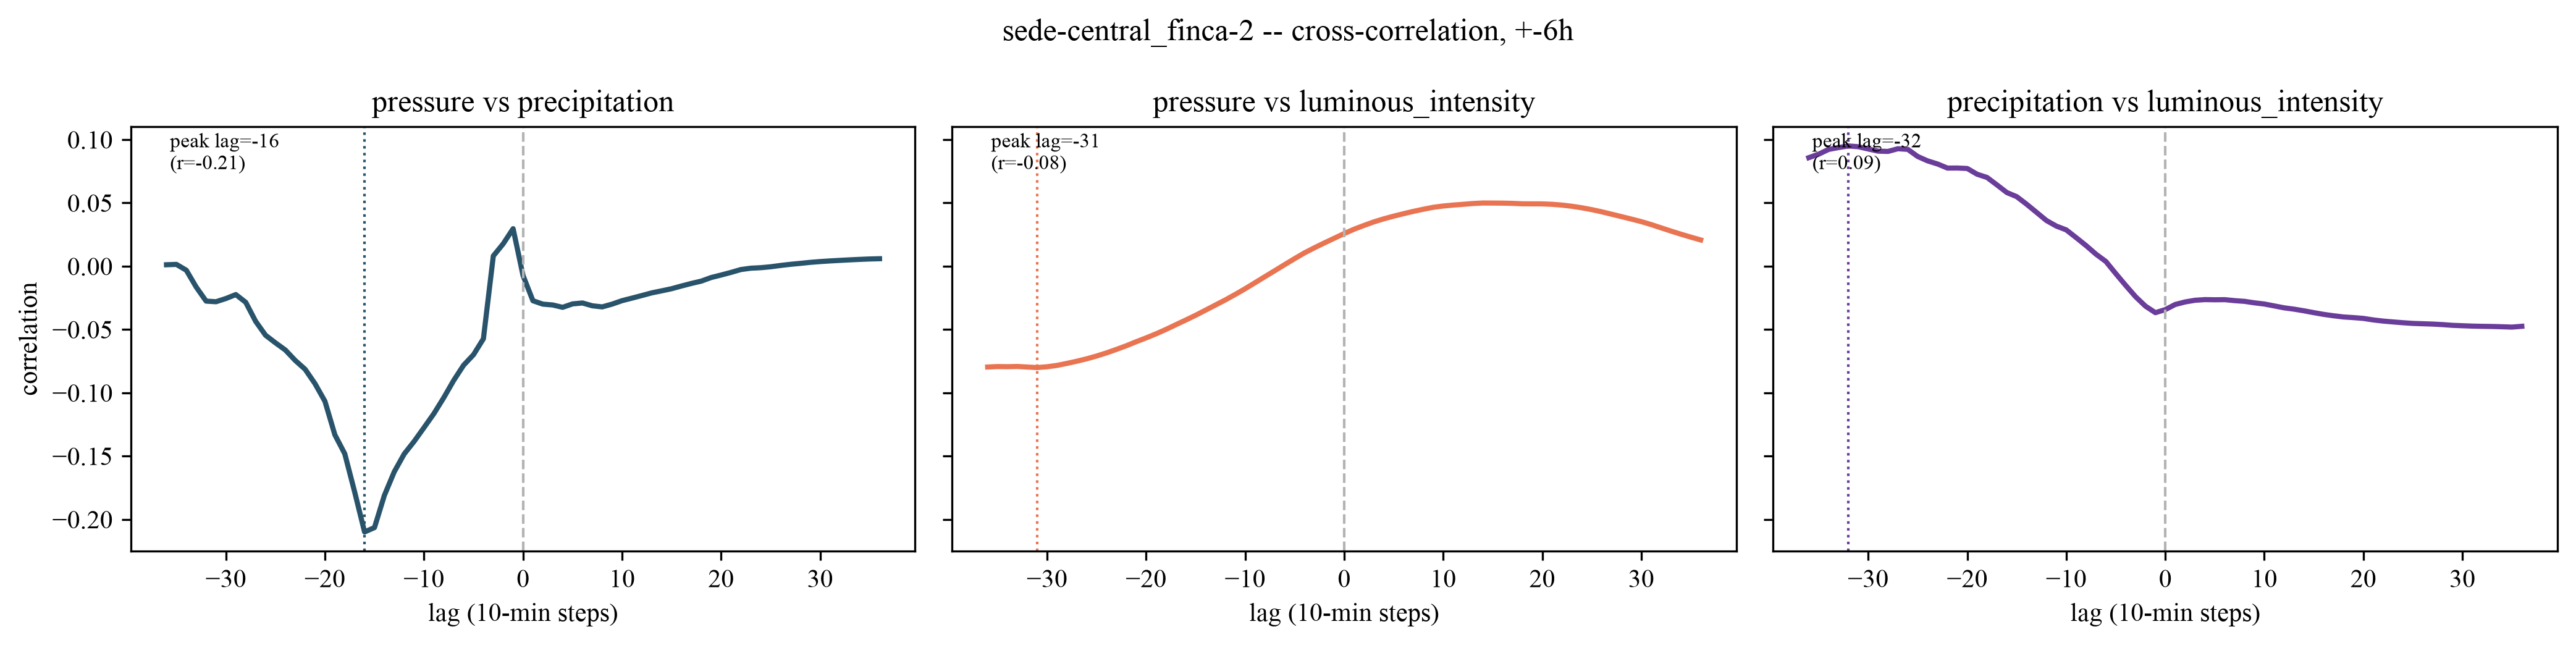

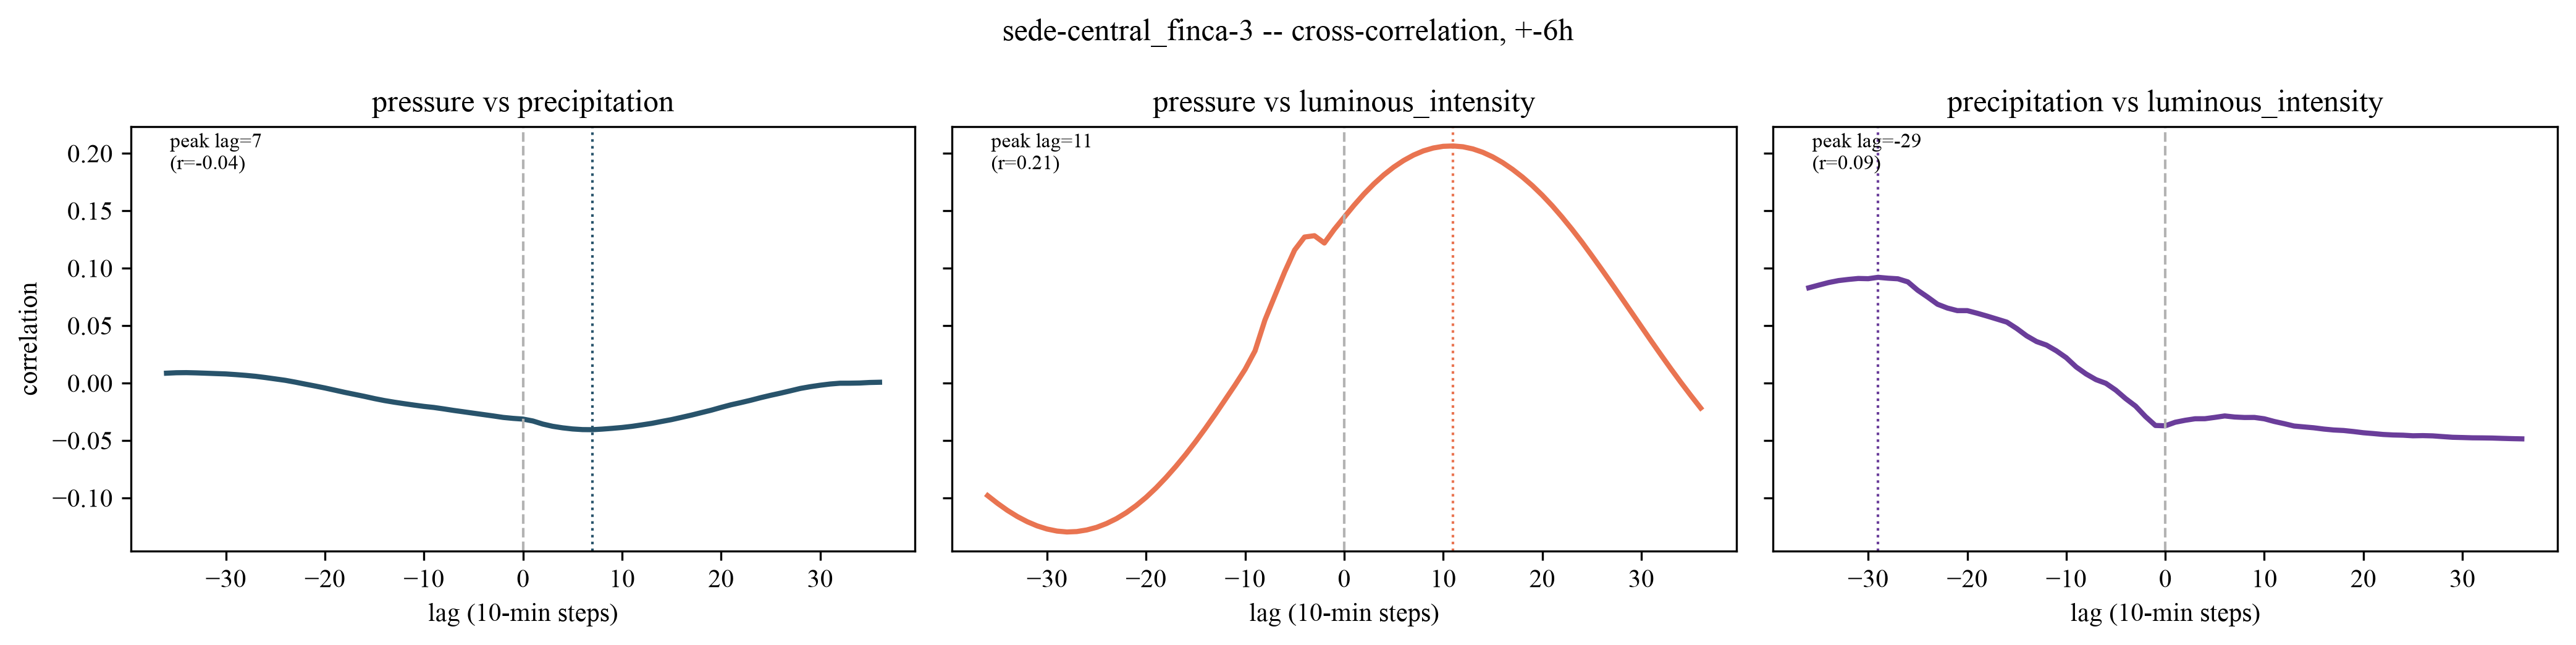

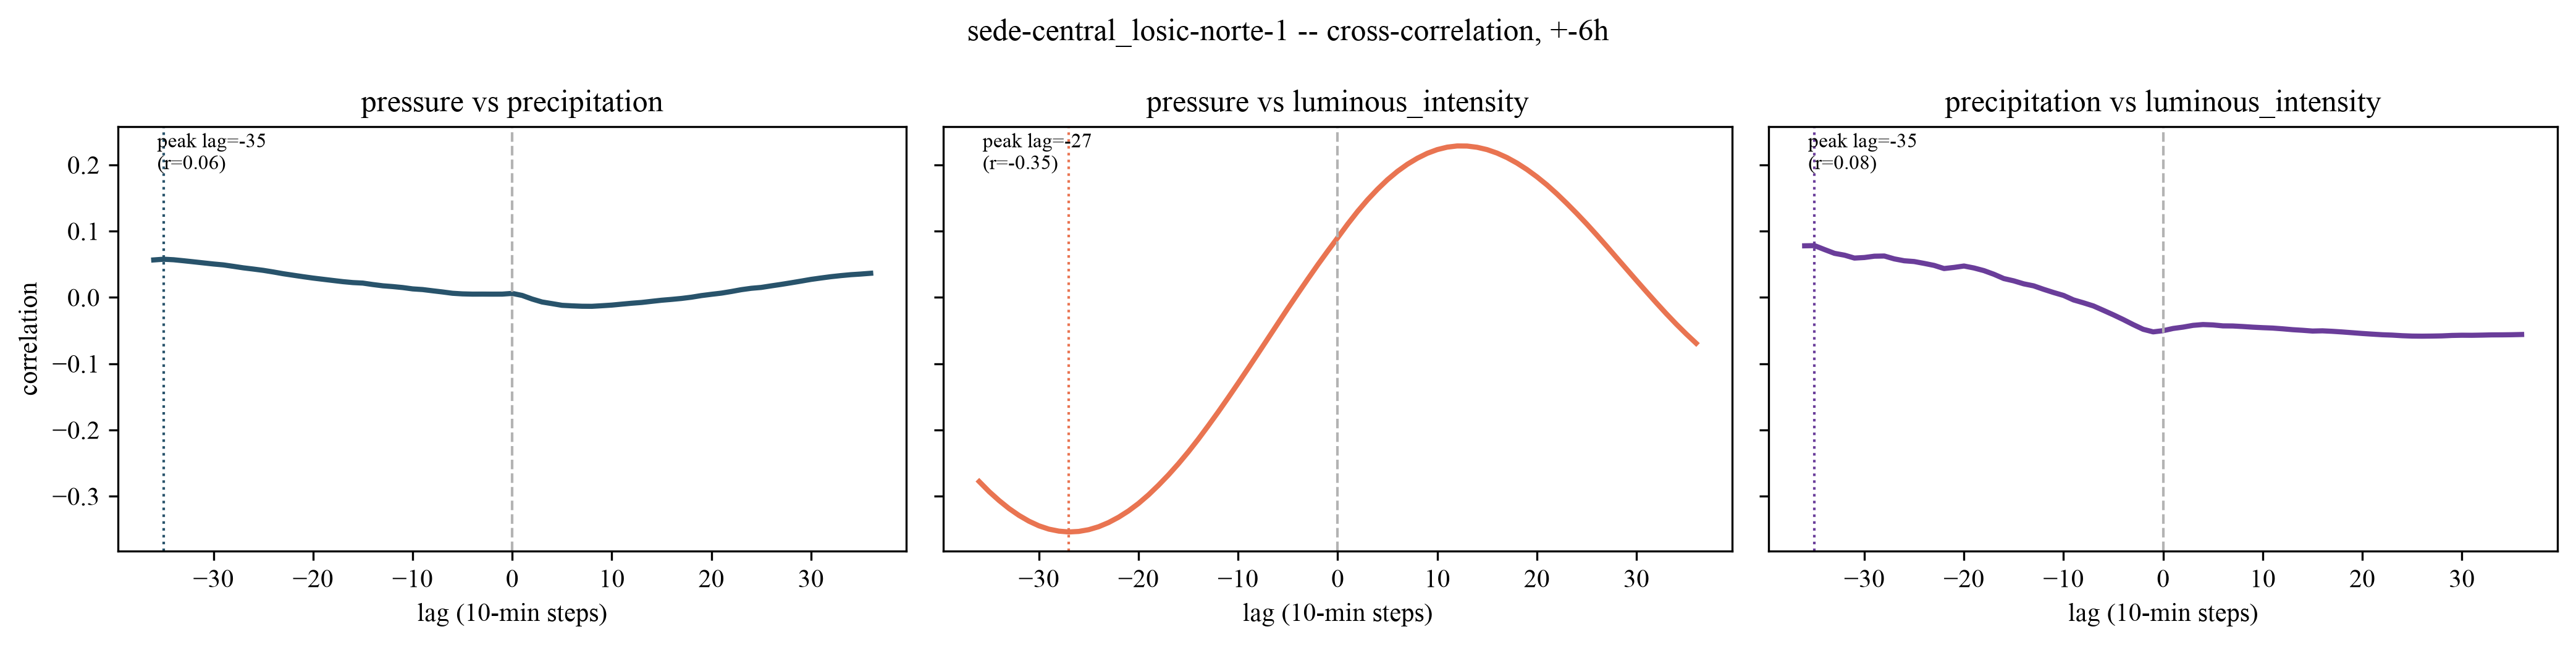

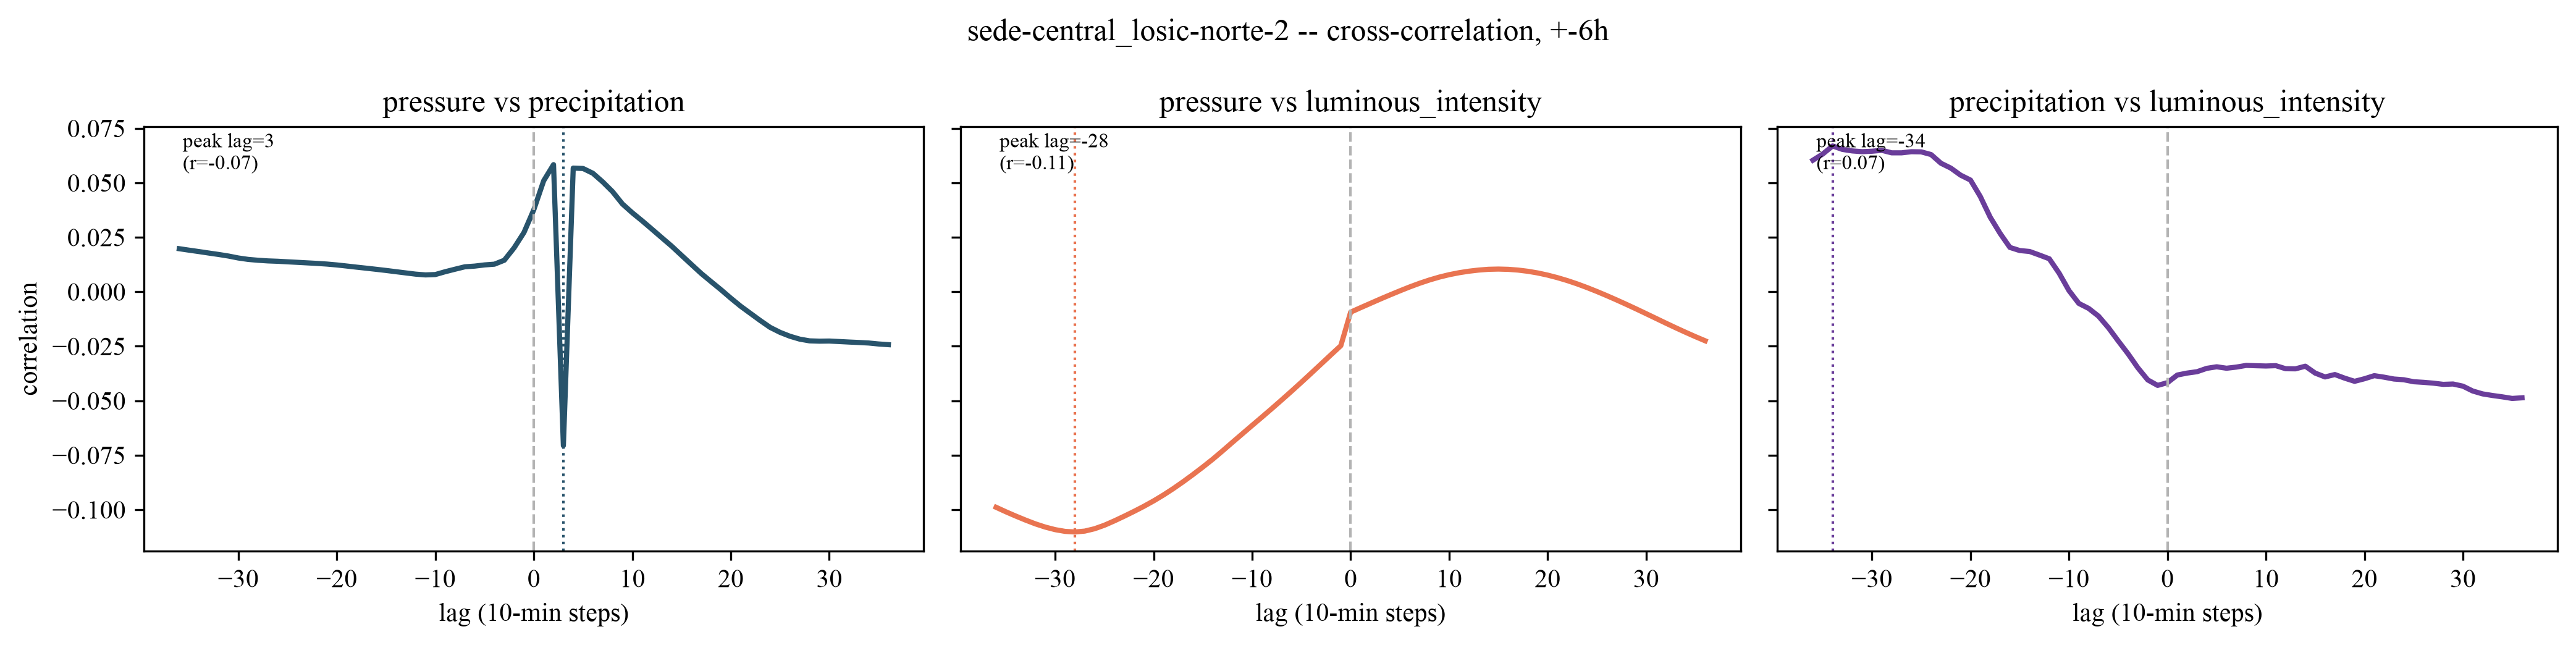

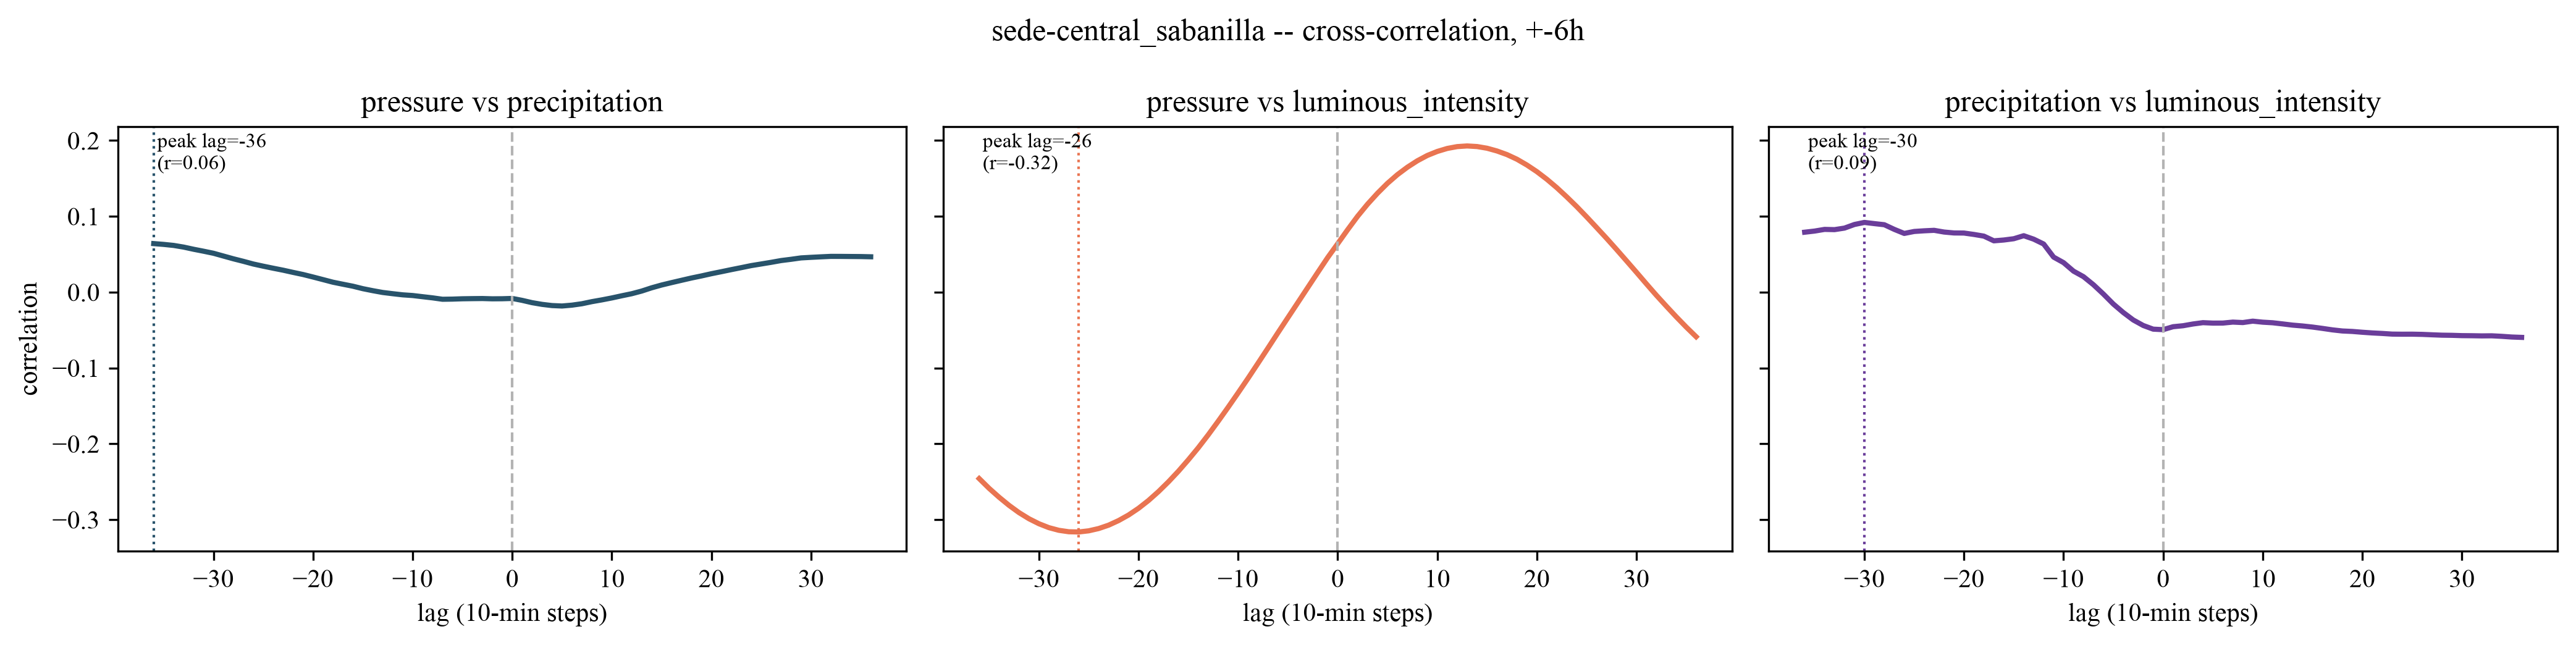

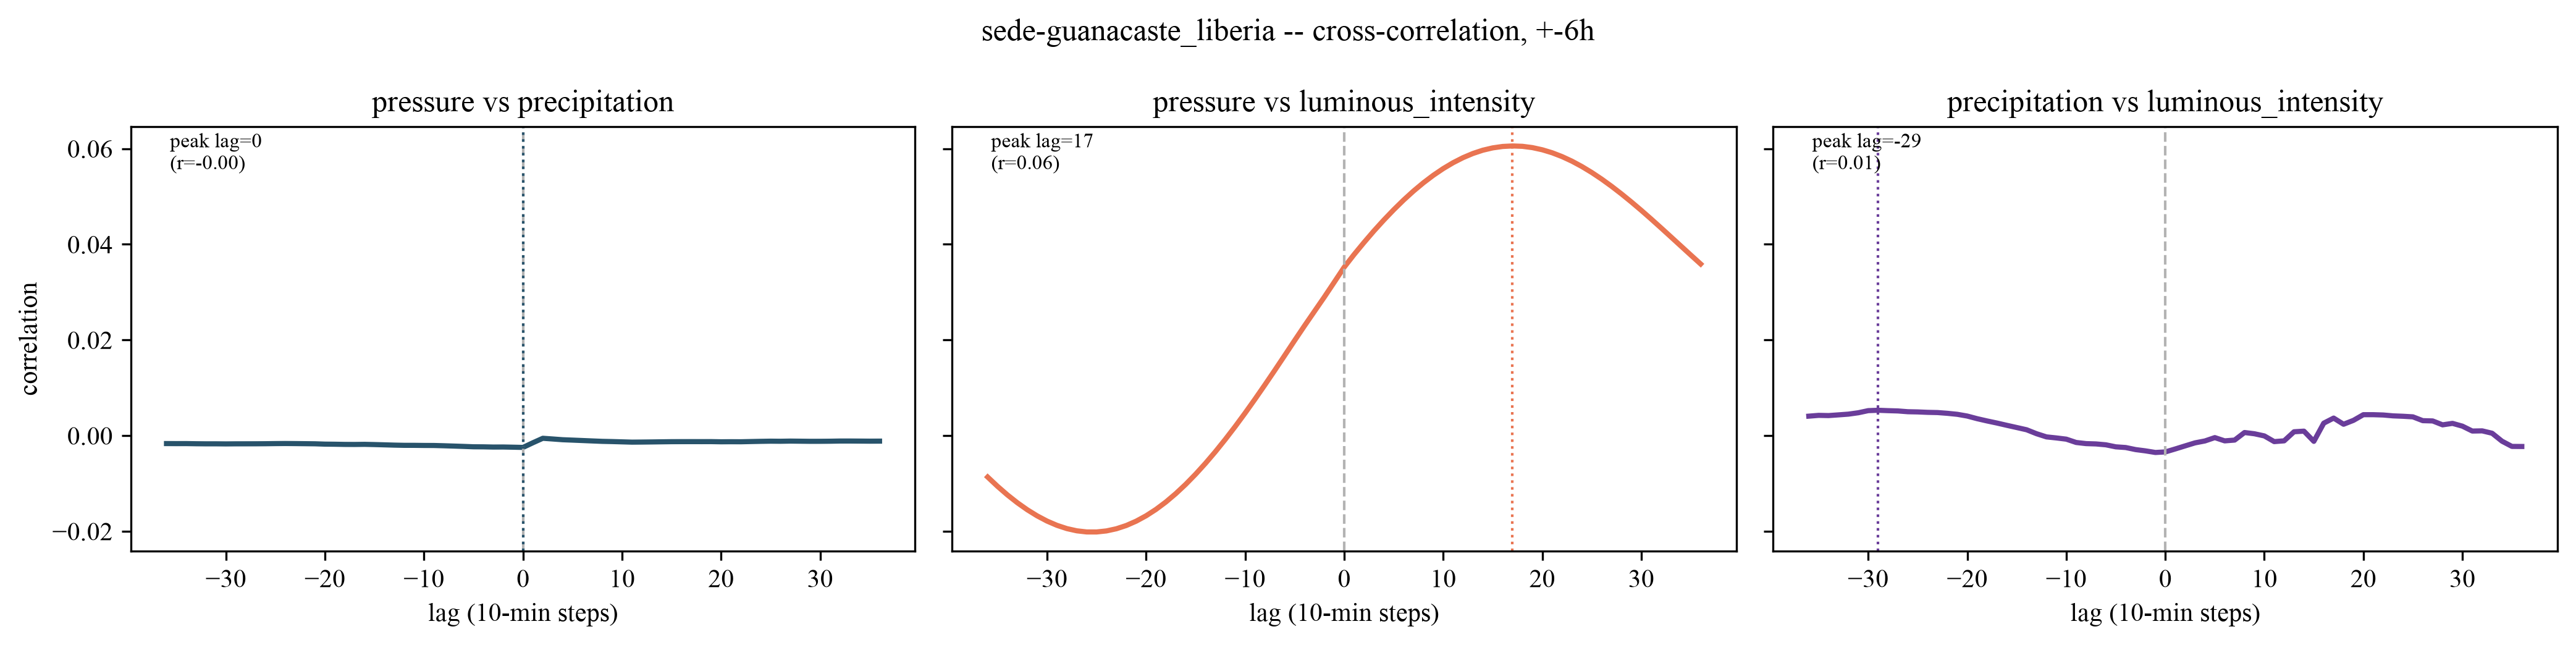

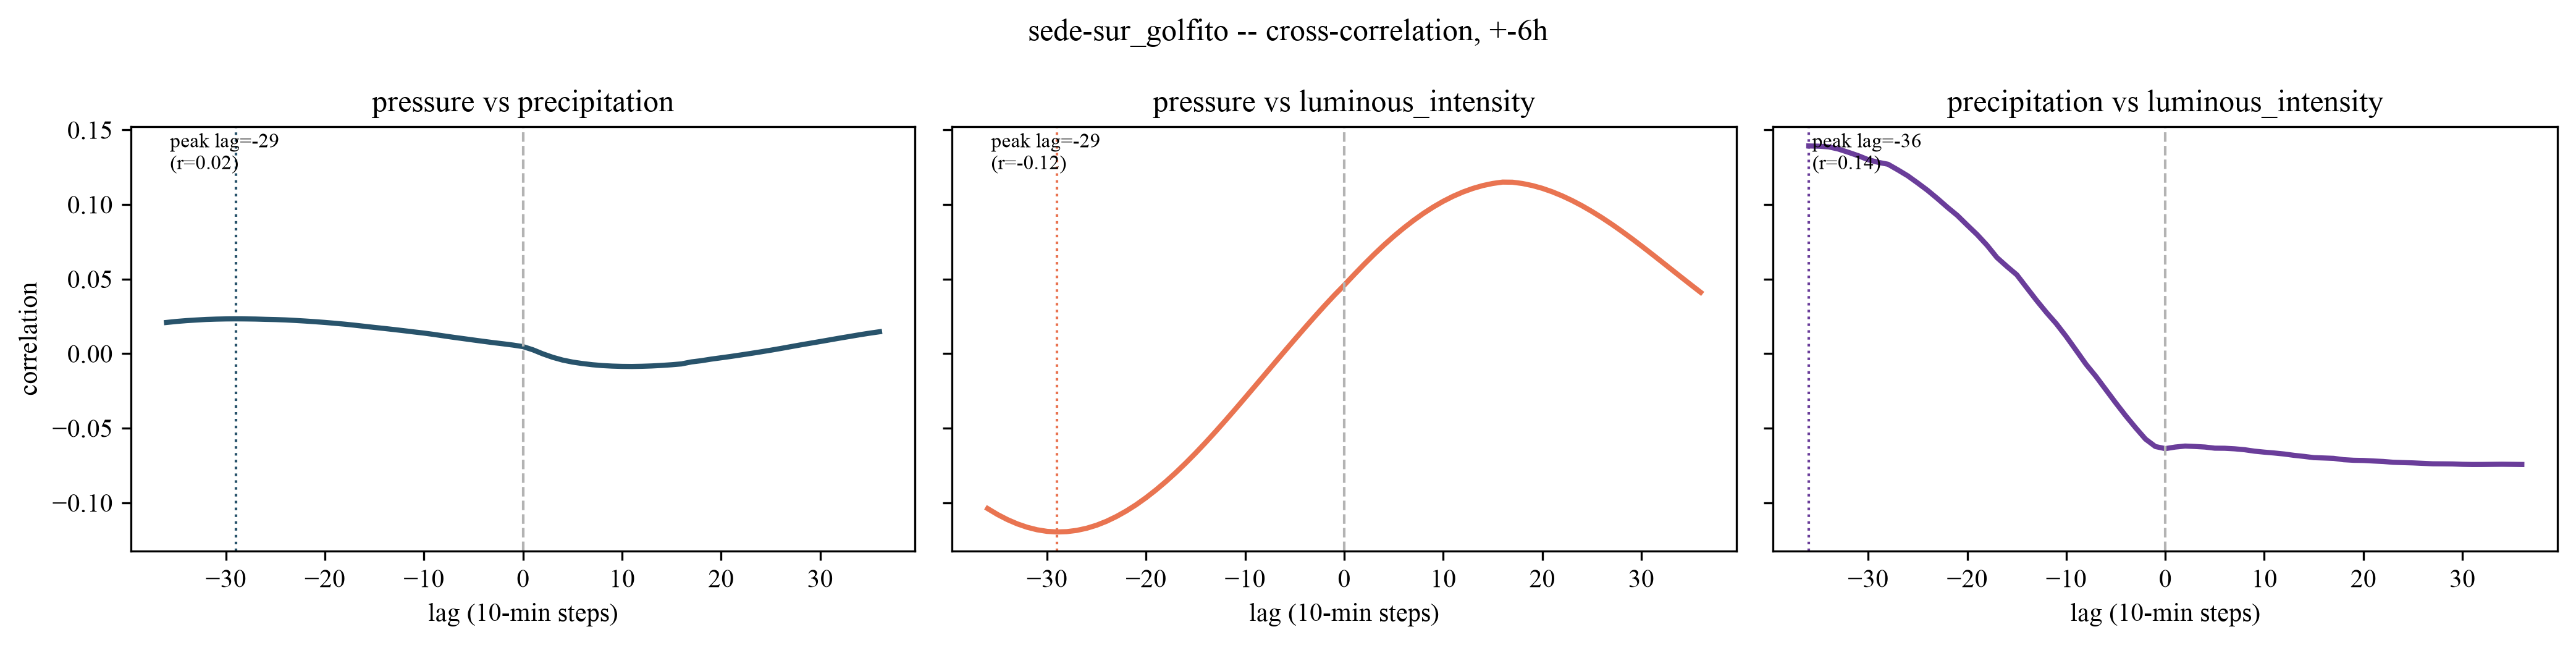

In [5]:
MAX_LAG = 36  # +-6h at a 10-minute sampling interval

ccf_results: dict[str, dict[tuple[str, str], pd.Series]] = {}
for station in STATIONS:
    ccf_results[station] = {}
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
    for ax, pair in zip(axes, PAIRS):
        var1, var2 = pair
        series = ccf(station_data[station], var1, var2, MAX_LAG)
        ccf_results[station][pair] = series
        series.to_csv(REPORT_DIR / f"{station}_ccf_{var1}_{var2}.csv", header=True)

        best_lag = series.abs().idxmax()
        best_value = series.loc[best_lag]

        ax.plot(series.index, series.values, color=PAIR_COLORS[pair], linewidth=2)
        ax.axvline(0, color="0.7", linewidth=1, linestyle="--")
        ax.axvline(best_lag, color=PAIR_COLORS[pair], linewidth=1, linestyle=":")
        ax.annotate(
            f"peak lag={best_lag}\n(r={best_value:.2f})",
            xy=(best_lag, best_value),
            xytext=(0.05, 0.9),
            textcoords="axes fraction",
            fontsize=8,
        )
        ax.set_title(f"{var1} vs {var2}")
        ax.set_xlabel("lag (10-min steps)")
    axes[0].set_ylabel("correlation")
    fig.suptitle(f"{station} -- cross-correlation, +-{MAX_LAG*10//60}h")
    fig.tight_layout()
    fig.savefig(REPORT_DIR / f"{station}_ccf.png", bbox_inches="tight")
    plt.show()


In [6]:
peak_rows = []
for station in STATIONS:
    for pair, series in ccf_results[station].items():
        best_lag = series.abs().idxmax()
        peak_rows.append(
            {
                "station": station,
                "pair": f"{pair[0]}-{pair[1]}",
                "peak_lag_steps": best_lag,
                "peak_lag_minutes": best_lag * 10,
                "peak_correlation": series.loc[best_lag],
                "lag0_correlation": series.loc[0],
            }
        )
ccf_peaks = pd.DataFrame(peak_rows)
ccf_peaks.to_csv(REPORT_DIR / "ccf_peak_summary.csv", index=False)
ccf_peaks


,station,pair,peak_lag_steps,peak_lag_minutes,peak_correlation,lag0_correlation
0,recinto-esparza,pressure-precipitation,-35,-350,0.061320,-0.004979
1,recinto-esparza,pressure-luminous_intensity,-26,-260,-0.341724,-0.010485
2,recinto-esparza,precipitation-luminous_intensity,-32,-320,0.091057,-0.045744
3,recinto-santa-cruz,pressure-precipitation,-29,-290,0.009087,0.008244
4,recinto-santa-cruz,pressure-luminous_intensity,-23,-230,-0.057012,-0.042464
5,recinto-santa-cruz,precipitation-luminous_intensity,-31,-310,0.059096,-0.031877
6,sede-atlantico_turrialba,pressure-precipitation,13,130,-0.044778,-0.012550
7,sede-atlantico_turrialba,pressure-luminous_intensity,-24,-240,-0.241362,0.036496
8,sede-atlantico_turrialba,precipitation-luminous_intensity,0,0,-0.070644,-0.070644
9,sede-central_finca-1,pressure-precipitation,-36,-360,0.028359,-0.009469


## Time-of-day and season conditioned correlation

Splits each station's data into day (06:00-17:59 local) / night (18:00-05:59
local) buckets, and into Costa Rica's dry (Dec-Apr) / wet (May-Nov) season
buckets, then recomputes the correlation matrices within each bucket
separately -- a pair that looks weak globally can still be strongly coupled
conditionally (e.g. only during daylight hours).


In [7]:
conditioned_rows = []
for station in STATIONS:
    for group_by in ("hour", "season"):
        buckets = conditioned_correlation(station_data[station], group_by=group_by)
        for bucket_label, corr in buckets.items():
            for var1, var2 in PAIRS:
                method = primary_method(var1, var2)
                value = corr[method].loc[var1, var2]
                conditioned_rows.append(
                    {
                        "station": station,
                        "group_by": group_by,
                        "bucket": bucket_label,
                        "pair": f"{var1}-{var2}",
                        "method": method,
                        "correlation": value,
                    }
                )
            corr["pearson"].to_csv(REPORT_DIR / f"{station}_{group_by}_{bucket_label}_pearson.csv")
            corr["spearman"].to_csv(REPORT_DIR / f"{station}_{group_by}_{bucket_label}_spearman.csv")

conditioned = pd.DataFrame(conditioned_rows)
conditioned.to_csv(REPORT_DIR / "conditioned_correlation_summary.csv", index=False)
conditioned.pivot_table(index=["station", "pair"], columns=["group_by", "bucket"], values="correlation")


group_by                                                         hour  \
bucket                                                            day   
station                    pair                                         
recinto-esparza            precipitation-luminous_intensity -0.208456   
                           pressure-luminous_intensity       0.072306   
                           pressure-precipitation           -0.017342   
recinto-santa-cruz         precipitation-luminous_intensity -0.112042   
                           pressure-luminous_intensity      -0.022263   
                           pressure-precipitation            0.009727   
sede-atlantico_turrialba   precipitation-luminous_intensity -0.242511   
                           pressure-luminous_intensity       0.149974   
                           pressure-precipitation            0.016889   
sede-central_finca-1       precipitation-luminous_intensity -0.114469   
                           pressure-luminous_intensity      -0.074013   
                           pressure-precipitation           -0.027209   
sede-central_finca-2       precipitation-luminous_intensity -0.177976   
                           pressure-luminous_intensity       0.076398   
                           pressure-precipitation           -0.059623   
sede-central_finca-3       precipitation-luminous_intensity -0.197764   
                           pressure-luminous_intensity       0.298091   
                           pressure-precipitation           -0.112800   
sede-central_losic-norte-1 precipitation-luminous_intensity -0.205915   
                           pressure-luminous_intensity       0.244791   
                           pressure-precipitation           -0.023556   
sede-central_losic-norte-2 precipitation-luminous_intensity -0.194602   
                           pressure-luminous_intensity      -0.059982   
                           pressure-precipitation           -0.067660   
sede-central_sabanilla     precipitation-luminous_intensity -0.238115   
                           pressure-luminous_intensity       0.152448   
                           pressure-precipitation           -0.017191   
sede-guanacaste_liberia    precipitation-luminous_intensity -0.103571   
                           pressure-luminous_intensity       0.100373   
                           pressure-precipitation            0.009340   
sede-sur_golfito           precipitation-luminous_intensity -0.262636   
                           pressure-luminous_intensity       0.104691   
                           pressure-precipitation           -0.025780   

group_by                                                               \
bucket                                                          night   
station                    pair                                         
recinto-esparza            precipitation-luminous_intensity -0.002830   
                           pressure-luminous_intensity      -0.034090   
                           pressure-precipitation            0.105606   
recinto-santa-cruz         precipitation-luminous_intensity  0.077012   
                           pressure-luminous_intensity      -0.310913   
                           pressure-precipitation            0.061386   
sede-atlantico_turrialba   precipitation-luminous_intensity  0.022858   
                           pressure-luminous_intensity      -0.022638   
                           pressure-precipitation            0.044755   
sede-central_finca-1       precipitation-luminous_intensity  0.004626   
                           pressure-luminous_intensity      -0.003277   
                           pressure-precipitation            0.038853   
sede-central_finca-2       precipitation-luminous_intensity -0.039492   
                           pressure-luminous_intensity      -0.051712   
                           pressure-precipitation            0.049210   
sede-central_finca-3       precipitation-luminous_intensi

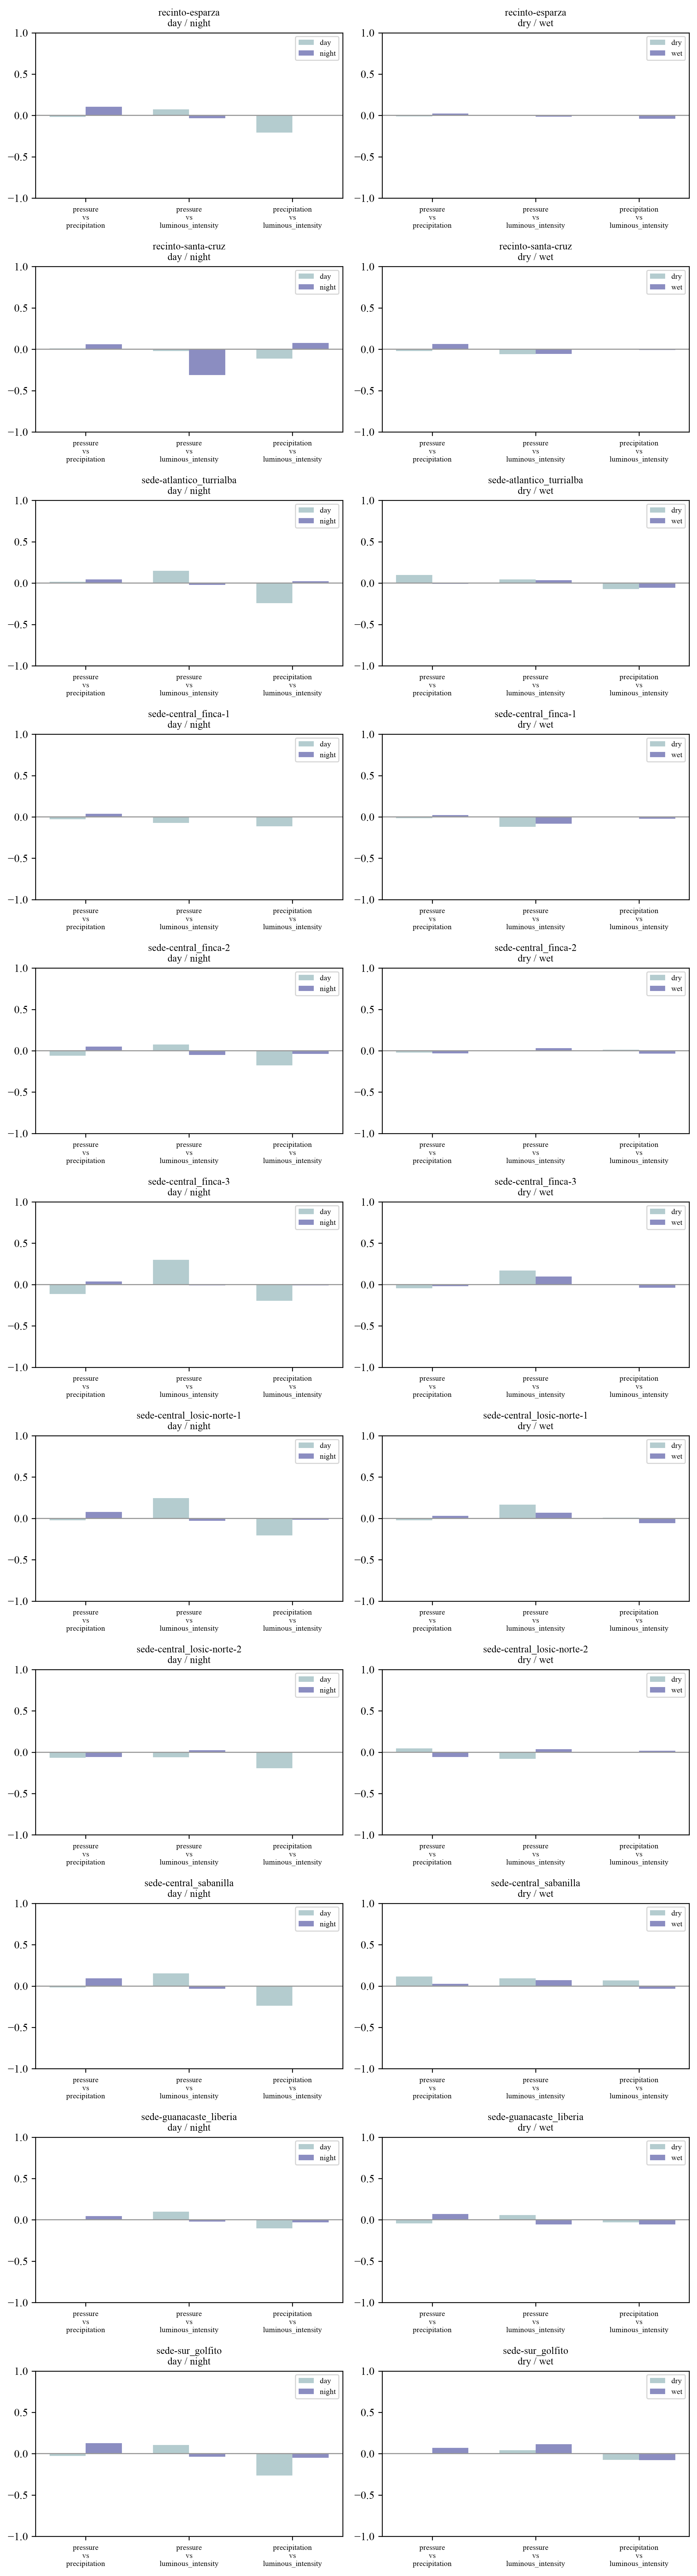

In [8]:
fig, axes = plt.subplots(len(STATIONS), 2, figsize=(9, 3 * len(STATIONS)))
for row, station in enumerate(STATIONS):
    hour_pivot = conditioned[(conditioned.station == station) & (conditioned.group_by == "hour")]
    season_pivot = conditioned[(conditioned.station == station) & (conditioned.group_by == "season")]

    for ax, pivot, group_label in ((axes[row, 0], hour_pivot, "day / night"), (axes[row, 1], season_pivot, "dry / wet")):
        buckets = sorted(pivot["bucket"].unique())
        x = np.arange(len(PAIRS))
        width = 0.35
        for i, bucket in enumerate(buckets):
            values = [pivot[(pivot.bucket == bucket) & (pivot.pair == f"{p[0]}-{p[1]}")]["correlation"].iloc[0] for p in PAIRS]
            color = PALETTE["azure"] if i == 0 else PALETTE["amethyst"]
            ax.bar(x + (i - 0.5) * width, values, width, label=bucket, color=color)
        ax.axhline(0, color="0.6", linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels([f"{p[0]}\nvs\n{p[1]}" for p in PAIRS], fontsize=7)
        ax.set_ylim(-1, 1)
        ax.set_title(f"{station}\n{group_label}", fontsize=9)
        ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(REPORT_DIR / "conditioned_correlation_bars.png", bbox_inches="tight")
plt.show()


## Feature Strategy Decision

**Global (lag-0) correlations stay small everywhere.** Across all 11
in-scope stations (3 GO + 8 CONDITIONAL-GO, each used over its full joint
span -- no rescue-window trimming) and all 3 sensor pairs, the primary-method
correlation (Spearman for pairs involving `precipitation`, Pearson otherwise)
never exceeds `|r| = 0.14` (`primary_correlation_summary.csv`; the largest is
`sede-central_finca-3`, `pressure`-`luminous_intensity`, `r = 0.14`). Still
far from what would justify treating the three sensors as one coupled
multivariate system by default.

**One conditional exception is real and worth naming, but its strength now
tracks data completeness closely enough that it needs a caveat this run
didn't need before:**

1. **`pressure`-`luminous_intensity` has a lagged relationship, but only
   clearly at the cleanest stations.** Sorting `ccf_peak_summary.csv` by
   each station's post-fill %missing (`post_fill_missingness.csv`) shows a
   sharp split: the five stations under 5% missing all show a clear peak
   (`r = -0.24` to `-0.43`, clustering 3.3-4.5h lag) --
   `sede-central_sabanilla` (-0.32), `sede-atlantico_turrialba` (-0.24),
   `recinto-esparza` (-0.34), `sede-central_losic-norte-1` (-0.35),
   `sede-central_finca-1` (-0.43). Every station above ~11% missing shows a
   weak, inconsistent, or even sign-flipped peak instead --
   `sede-sur_golfito` (-0.12 at 11.3% missing), `sede-central_finca-2`
   (-0.08 at 26.9%), `sede-guanacaste_liberia` (+0.06 at 28.3%),
   `recinto-santa-cruz` (-0.06 at 33.0%), `sede-central_finca-3` (+0.21 at
   36.4% -- opposite sign from the clean-station pattern),
   `sede-central_losic-norte-2` (-0.11 at 51.0%). Dropping the windowed
   rescue mechanism (Step 0) means these heavily-gapped stations are now
   included over their raw joint span instead of a clean sub-window, and
   this is the direct, visible cost of that choice: real signal at clean
   stations gets washed out (or produces artifacts, as at `finca-3`) once
   missingness climbs past roughly 10-15%. Read the CCF peak at any station
   above that threshold with caution, not as evidence the coupling is
   physically absent there.
2. **`precipitation`-`luminous_intensity` strengthens specifically during
   daytime hours, at all 11 stations regardless of completeness.** Daytime
   `r` ranges `-0.10` (`sede-guanacaste_liberia`) to `-0.26`
   (`sede-sur_golfito`), versus `|r| <= 0.08` at night at every station
   (`conditioned_correlation_summary.csv`) -- physically consistent (rain
   clouds suppress daytime light readings), and, unlike the lagged
   pressure-lux coupling, this pattern holds up uniformly even at the
   messiest stations, suggesting it's a coarser, more robust effect than a
   precise multi-hour lag estimate.

**Decision:** treat the three sensors as **independent, per-sensor
(univariate) series by default** for Step 3 -- lag-0 correlation stays weak
across all 11 stations. Carry a lagged/joint feature for
`pressure`-`luminous_intensity`, but weight it by each station's data
completeness (strong evidence at the 5 stations under 5% missing, unreliable
above ~10-15%) rather than treating it as a uniform network-wide constant.
Account for the `precipitation`-`luminous_intensity` daytime coupling in any
time-of-day-sensitive method -- this one holds regardless of completeness.
This completeness-dependence is itself a useful finding from dropping the
windowed-rescue mechanism: it makes explicit, station by station, how much
to trust each result, rather than presenting one clean number that hides
which stations it's actually resting on.
